轨迹处理
1. 对点：删掉地面运行轨迹点
2. 对轨迹：含有跳变点的轨迹直接删除
3. 重采样、归一化
4. 再放入ae中

In [1]:
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

# ---- paths ---------------------------------------------------------------
_WEEKS = [
    ("E:/data/哈尔滨20250728-20250803/哈尔滨20250728-20250803/", "2025-07-28", 7),
    ("E:/data/哈尔滨20251215-20251221/哈尔滨20251215-20251221/", "2025-12-15", 7),
]

file_paths = [
    os.path.join(base,
        (datetime.strptime(start, "%Y-%m-%d") + timedelta(days=i)).strftime("%Y-%m-%d") + ".csv")
    for base, start, days in _WEEKS
    for i in range(days)
]

OUT_DIR = "haerbin_output"
os.makedirs(OUT_DIR, exist_ok=True)

# ---- trajectory parameters -----------------------------------------------
T             = 100          # points per trajectory after resampling
MIN_POINTS    = 50           # discard segments shorter than this
GAP_THRESHOLD = 10 * 60      # flight segmentation threshold (seconds)

# ---- altitude filter range -----------------------------------------------
ALT_MIN = 0
ALT_MAX = 15000

# ---- file names -----------------------------------------------------------
RESAMPLED_CSV   = os.path.join(OUT_DIR, "haerbin_resampled.csv")
SCALER_PATH     = os.path.join(OUT_DIR, "haerbin_scaler.joblib")
FC_MODEL_PATH   = os.path.join(OUT_DIR, "haerbin_fc_ae.pth")
LSTM_MODEL_PATH = os.path.join(OUT_DIR, "haerbin_lstm_ae.pth")
GRU_MODEL_PATH  = os.path.join(OUT_DIR, "haerbin_gru_ae.pth")

print(f"配置完成，共 {len(file_paths)} 个文件（{len(_WEEKS)} 周）:")
for p in file_paths:
    exists = "✓" if os.path.exists(p) else "✗"
    print(f"  {exists} {os.path.basename(p)}")


配置完成，共 14 个文件（2 周）:
  ✓ 2025-07-28.csv
  ✓ 2025-07-29.csv
  ✓ 2025-07-30.csv
  ✓ 2025-07-31.csv
  ✓ 2025-08-01.csv
  ✓ 2025-08-02.csv
  ✓ 2025-08-03.csv
  ✓ 2025-12-15.csv
  ✓ 2025-12-16.csv
  ✓ 2025-12-17.csv
  ✓ 2025-12-18.csv
  ✓ 2025-12-19.csv
  ✓ 2025-12-20.csv
  ✓ 2025-12-21.csv


In [2]:
# ── 哈尔滨太平国际机场 WGS84 坐标 ─────────────────────────────────
AIRPORT_LAT = 45.623403
AIRPORT_LON = 126.250328
AIRPORT_RADIUS_NM = 20        # 海里；轨迹最低高度点距机场 ≤ 此值 → 视为在此机场起降
AIRPORT_RADIUS_KM = AIRPORT_RADIUS_NM * 1.852   # ≈ 37.0 km

# ── 经停/过站分割参数 ──────────────────────────────────────────────
GROUND_HEIGHT_THR  = 20    # m；altitude ≤ 此值视为地面（AGL 优先）
GROUND_DWELL_SEC   = 600   # s；连续地面时间超过此值 → 在此处分割（默认 10 分钟）


def _haversine_km(lat1, lon1, lat2, lon2):
    """向量化 Haversine 距离（km）。lat1/lon1 可以是数组，lat2/lon2 为标量。"""
    R = 6371.0
    rlat1, rlat2 = np.radians(lat1), np.radians(lat2)
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat / 2) ** 2 + np.cos(rlat1) * np.cos(rlat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))


def _split_ground_dwell(df_seg, ground_thr=GROUND_HEIGHT_THR,
                         dwell_sec=GROUND_DWELL_SEC):
    """
    检测一条轨迹中连续在地面超过 dwell_sec 的驻留段（经停/过站），
    在驻留段处将轨迹切分为多段，丢弃地面驻留部分。

    返回：list of DataFrame，每项为切分后的一个子段。
    若无驻留或全在地面则返回原始段（包在列表中）。
    """
    if "height" in df_seg.columns:
        h = df_seg["height"].to_numpy(dtype=float)
        nan_m = np.isnan(h)
        if nan_m.any():
            h[nan_m] = df_seg["altitude"].to_numpy(dtype=float)[nan_m]
    else:
        h = df_seg["altitude"].to_numpy(dtype=float)
    h = np.nan_to_num(h, nan=0.0)

    on_ground = h <= ground_thr
    n = len(df_seg)
    ts = df_seg["position_time"].values

    ground_blocks = []
    i = 0
    while i < n:
        if on_ground[i]:
            j = i
            while j < n and on_ground[j]:
                j += 1
            dur = (ts[j - 1] - ts[i]) / np.timedelta64(1, "s")
            if dur >= dwell_sec:
                ground_blocks.append((i, j - 1))
            i = j
        else:
            i += 1

    if not ground_blocks:
        return [df_seg]

    sub_segs = []
    prev_end = 0
    for (gs, ge) in ground_blocks:
        air_part = df_seg.iloc[prev_end:gs]
        if len(air_part) > 0:
            sub_segs.append(air_part)
        prev_end = ge + 1
    tail = df_seg.iloc[prev_end:]
    if len(tail) > 0:
        sub_segs.append(tail)

    return sub_segs if sub_segs else [df_seg]


def preprocess_stage1(file_path, date_str, gap_sec=GAP_THRESHOLD):
    """
    Stage 1：读取 CSV → 基础过滤 → 排序 → 时间间隔分割 → 地面驻留分割 → 机场筛选
    不含去重和去短，保留最大轨迹数量供统计使用。
    """
    core_cols  = ["icao", "lng", "lat", "altitude", "position_time"]
    extra_cols = ["speed", "ver_speed", "callsign", "height", "heading", "ver_speed_type"]

    try:
        df = pd.read_csv(file_path, encoding="utf-8", usecols=core_cols + extra_cols)
    except UnicodeDecodeError:
        df = pd.read_csv(file_path, encoding="gbk",  usecols=core_cols + extra_cols)
    except ValueError:
        header = pd.read_csv(file_path, nrows=0)
        available = core_cols + [c for c in extra_cols if c in header.columns]
        try:
            df = pd.read_csv(file_path, encoding="utf-8", usecols=available)
        except UnicodeDecodeError:
            df = pd.read_csv(file_path, encoding="gbk",  usecols=available)

    print(f"  读取 {len(df):,} 行 ({os.path.basename(file_path)})")

    # ── 1. 基础过滤 ───────────────────────────────────────────────
    df = df.dropna(subset=["lng", "lat", "altitude", "position_time"])
    df = df[(df["altitude"] >= ALT_MIN) & (df["altitude"] <= ALT_MAX)]
    df["position_time"] = pd.to_datetime(df["position_time"], unit="ms", utc=True)

    # ── 排序 ──────────────────────────────────────────────────────
    df = df.sort_values(["icao", "position_time"]).reset_index(drop=True)

    # ── 2. 按时间间隔分割轨迹 ─────────────────────────────────────
    df["_dt"]  = df.groupby("icao")["position_time"].diff().dt.total_seconds().fillna(0)
    df["_new"] = (df["_dt"] > gap_sec) | (df["icao"] != df["icao"].shift(1))
    df["_seg"] = df.groupby("icao")["_new"].cumsum()
    df["flight_id"] = (
        df["icao"].astype(str) + "_" + date_str.replace("-", "") + "_"
        + df["_seg"].astype(str).str.zfill(3)
    )
    n_seg_after_gap = df["flight_id"].nunique()

    # ── 3. 地面驻留二次分割（经停/过站检测） ─────────────────────
    all_parts = []
    n_split_count = 0
    sub_id_counter = {}
    for fid, grp in df.groupby("flight_id", sort=False):
        sub_segs = _split_ground_dwell(grp)
        if len(sub_segs) > 1:
            n_split_count += 1
        for sub in sub_segs:
            cnt = sub_id_counter.get(fid, 0)
            new_fid = fid if len(sub_segs) == 1 else f"{fid}_{chr(ord('a') + cnt)}"
            sub_id_counter[fid] = cnt + 1
            sub = sub.copy()
            sub["flight_id"] = new_fid
            all_parts.append(sub)

    df = pd.concat(all_parts, ignore_index=True) if all_parts else df.iloc[0:0].copy()
    n_seg_after_dwell = df["flight_id"].nunique()
    print(f"  时间分割: {n_seg_after_gap:,} 条 → 地面驻留分割后: "
          f"{n_seg_after_dwell:,} 条（{n_split_count:,} 条经停被切开）")

    # ── 4. 筛选哈尔滨太平机场起降轨迹 ────────────────────────────
    df["_dist_to_apt"] = _haversine_km(
        df["lat"].values, df["lng"].values, AIRPORT_LAT, AIRPORT_LON
    )

    def _is_airport_flight(grp):
        alt = grp["altitude"].values
        thr = np.percentile(alt, 10)
        low_mask = alt <= max(thr, 500)
        if not low_mask.any():
            low_mask = alt <= alt.min() + 200
        return grp.loc[low_mask, "_dist_to_apt"].min() <= AIRPORT_RADIUS_KM

    airport_flags = df.groupby("flight_id", sort=False).apply(_is_airport_flight)
    airport_fids  = airport_flags.index[airport_flags]
    n_other = n_seg_after_dwell - len(airport_fids)
    df = df[df["flight_id"].isin(airport_fids)].copy()
    print(f"  机场筛选: 保留 {len(airport_fids):,} 条，过滤路过/其他 {n_other:,} 条")

    keep = ["flight_id", "icao", "lng", "lat", "altitude", "position_time"] + \
           [c for c in extra_cols if c in df.columns]
    return df[keep].reset_index(drop=True)


# ── 逐日 Stage 1：时间分割 + 地面驻留分割 + 机场筛选（不去重、不去短）──
_raw_parts = []
_n_files = len(file_paths)

for _i, _fp in enumerate(file_paths):
    _date_str = os.path.splitext(os.path.basename(_fp))[0]
    if not os.path.exists(_fp):
        print(f"[{_i+1}/{_n_files}] ✗ 文件不存在: {_fp}")
        continue
    print(f"[{_i+1}/{_n_files}] {_date_str} ...")
    _df_day = preprocess_stage1(_fp, _date_str)
    _raw_parts.append(_df_day)

df_raw_segmented = pd.concat(_raw_parts, ignore_index=True) if _raw_parts else pd.DataFrame()
print(f"\nStage 1 完成：共 {df_raw_segmented['flight_id'].nunique():,} 条轨迹，"
      f"{len(df_raw_segmented):,} 个数据点")


[1/14] 2025-07-28 ...
  读取 690,998 行 (2025-07-28.csv)
  时间分割: 558 条 → 地面驻留分割后: 563 条（5 条经停被切开）


C:\Users\93176\AppData\Local\Temp\ipykernel_44108\169812679.py:149: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  airport_flags = df.groupby("flight_id", sort=False).apply(_is_airport_flight)


  机场筛选: 保留 512 条，过滤路过/其他 51 条
[2/14] 2025-07-29 ...
  读取 663,584 行 (2025-07-29.csv)


KeyboardInterrupt: 

In [3]:
# ── 哈尔滨太平国际机场 WGS84 坐标 ─────────────────────────────────
AIRPORT_LAT = 45.623403
AIRPORT_LON = 126.250328
AIRPORT_RADIUS_NM = 20        # 海里；轨迹最低高度点距机场 ≤ 此值 → 视为在此机场起降
AIRPORT_RADIUS_KM = AIRPORT_RADIUS_NM * 1.852   # ≈ 37.0 km

# ── 经停/过站分割参数 ──────────────────────────────────────────────
GROUND_HEIGHT_THR  = 20    # m；altitude ≤ 此值视为地面（AGL 优先）
GROUND_DWELL_SEC   = 600   # s；连续地面时间超过此值 → 在此处分割（默认 10 分钟）


def _haversine_km(lat1, lon1, lat2, lon2):
    """向量化 Haversine 距离（km）。lat1/lon1 可以是数组，lat2/lon2 为标量。"""
    R = 6371.0
    rlat1, rlat2 = np.radians(lat1), np.radians(lat2)
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat / 2) ** 2 + np.cos(rlat1) * np.cos(rlat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))


def preprocess_one_day(file_path, date_str, gap_sec=GAP_THRESHOLD, min_pts=MIN_POINTS):
    """
    处理流程：
      1. 读取 CSV，基础过滤（NaN、高度范围）
      2. 去除重复值（同一 icao 同一 position_time 的重复行）
      3. 按时间间隔分割轨迹
      4. 筛选广州白云机场起降轨迹（轨迹最低高度点距机场 ≤ 30 NM）
      5. 去除过短轨迹
    """
    core_cols  = ["icao", "lng", "lat", "altitude", "position_time"]
    extra_cols = ["speed", "ver_speed", "callsign", "height", "heading", "ver_speed_type"]

    try:
        df = pd.read_csv(file_path, encoding="utf-8", usecols=core_cols + extra_cols)
    except UnicodeDecodeError:
        df = pd.read_csv(file_path, encoding="gbk",  usecols=core_cols + extra_cols)
    except ValueError:
        header = pd.read_csv(file_path, nrows=0)
        available = core_cols + [c for c in extra_cols if c in header.columns]
        try:
            df = pd.read_csv(file_path, encoding="utf-8", usecols=available)
        except UnicodeDecodeError:
            df = pd.read_csv(file_path, encoding="gbk",  usecols=available)

    print(f"  读取 {len(df):,} 行 ({os.path.basename(file_path)})")

    # ── 1. 基础过滤 ───────────────────────────────────────────────
    df = df.dropna(subset=["lng", "lat", "altitude", "position_time"])
    df = df[(df["altitude"] >= ALT_MIN) & (df["altitude"] <= ALT_MAX)]
    df["position_time"] = pd.to_datetime(df["position_time"], unit="ms", utc=True)
    print(f"  基础过滤后: {len(df):,} 行")

    # ── 2. 去除重复值 ─────────────────────────────────────────────
    n_before_dedup = len(df)
    df = df.drop_duplicates(subset=["icao", "position_time", "lng", "lat", "altitude"])
    n_dedup_removed = n_before_dedup - len(df)
    print(f"  去重: 删除 {n_dedup_removed:,} 行重复值，剩余 {len(df):,} 行")

    # ── 排序 ──────────────────────────────────────────────────────
    df = df.sort_values(["icao", "position_time"]).reset_index(drop=True)

    # ── 3. 按时间间隔分割轨迹 ─────────────────────────────────────
    df["_dt"]  = df.groupby("icao")["position_time"].diff().dt.total_seconds().fillna(0)
    df["_new"] = (df["_dt"] > gap_sec) | (df["icao"] != df["icao"].shift(1))
    df["_seg"] = df.groupby("icao")["_new"].cumsum()
    df["flight_id"] = (
        df["icao"].astype(str) + "_" + date_str.replace("-", "") + "_"
        + df["_seg"].astype(str).str.zfill(3)
    )
    n_seg_total = df["flight_id"].nunique()

    # ── 4. 筛选广州白云机场起降轨迹 ────────────────────────────
    #    判断逻辑：取每条轨迹高度最低的 10% 的点（即起飞/降落阶段），
    #    计算这些低空点到机场的最小距离。
    #    若 ≤ AIRPORT_RADIUS_KM → 该轨迹在白云机场起降，保留。
    #    这样路过高空飞越的航班会被过滤掉。
    df["_dist_to_apt"] = _haversine_km(
        df["lat"].values, df["lng"].values, AIRPORT_LAT, AIRPORT_LON
    )

    def _is_airport_flight(grp):
        alt = grp["altitude"].values
        thr = np.percentile(alt, 10)         # 高度最低 10% 分位
        low_mask = alt <= max(thr, 500)       # 至少取 ≤500m 的点
        if not low_mask.any():
            low_mask = alt <= alt.min() + 200  # fallback：最低高度 +200m
        return grp.loc[low_mask, "_dist_to_apt"].min() <= AIRPORT_RADIUS_KM

    airport_flags = df.groupby("flight_id", sort=False).apply(_is_airport_flight)
    airport_fids  = airport_flags.index[airport_flags]
    n_airport = len(airport_fids)
    n_other   = n_seg_total - n_airport
    df = df[df["flight_id"].isin(airport_fids)].copy()
    print(f"  机场筛选: {n_seg_total:,} 条 → 白云机场起降 {n_airport:,} 条"
          f"（过滤路过/其他机场 {n_other:,} 条，阈值 {AIRPORT_RADIUS_NM} NM）")

    # ── 5. 去除过短轨迹 ──────────────────────────────────────────
    seg_len = df.groupby("flight_id")["lng"].count()
    valid   = seg_len.index[seg_len >= min_pts]
    n_short = len(seg_len) - len(valid)
    df = df[df["flight_id"].isin(valid)].copy()
    print(f"  去除过短（< {min_pts} 点）: 删除 {n_short:,} 条，保留 {df['flight_id'].nunique():,} 条")

    keep = ["flight_id", "icao", "lng", "lat", "altitude", "position_time"] + \
           [c for c in extra_cols if c in df.columns]
    return df[keep].reset_index(drop=True)


# ── 逐日处理 ──────────────────────────────────────────────────────
_n_files = len(file_paths)
daily_parquets = []

for i, fp in enumerate(file_paths):
    date_str = os.path.splitext(os.path.basename(fp))[0]
    out_pq   = os.path.join(OUT_DIR, f"{date_str}.parquet")
    daily_parquets.append(out_pq)

    if os.path.exists(out_pq):
        print(f"[{i+1}/{_n_files}] {date_str}: parquet 已存在，跳过。")
        continue
    if not os.path.exists(fp):
        print(f"[{i+1}/{_n_files}] {date_str}: CSV 不存在，跳过。")
        continue

    print(f"[{i+1}/{_n_files}] 处理 {date_str} ...")
    df_day = preprocess_one_day(fp, date_str)
    df_day.to_parquet(out_pq, index=False)
    print(f"  保存 -> {out_pq}  ({len(df_day):,} 行, {df_day['flight_id'].nunique():,} 条轨迹)")

[1/14] 2025-07-28: parquet 已存在，跳过。
[2/14] 2025-07-29: parquet 已存在，跳过。
[3/14] 2025-07-30: parquet 已存在，跳过。
[4/14] 2025-07-31: parquet 已存在，跳过。
[5/14] 2025-08-01: parquet 已存在，跳过。
[6/14] 2025-08-02: parquet 已存在，跳过。
[7/14] 2025-08-03: parquet 已存在，跳过。
[8/14] 2025-12-15: parquet 已存在，跳过。
[9/14] 2025-12-16: parquet 已存在，跳过。
[10/14] 2025-12-17: parquet 已存在，跳过。
[11/14] 2025-12-18: parquet 已存在，跳过。
[12/14] 2025-12-19: parquet 已存在，跳过。
[13/14] 2025-12-20: parquet 已存在，跳过。
[14/14] 2025-12-21: parquet 已存在，跳过。


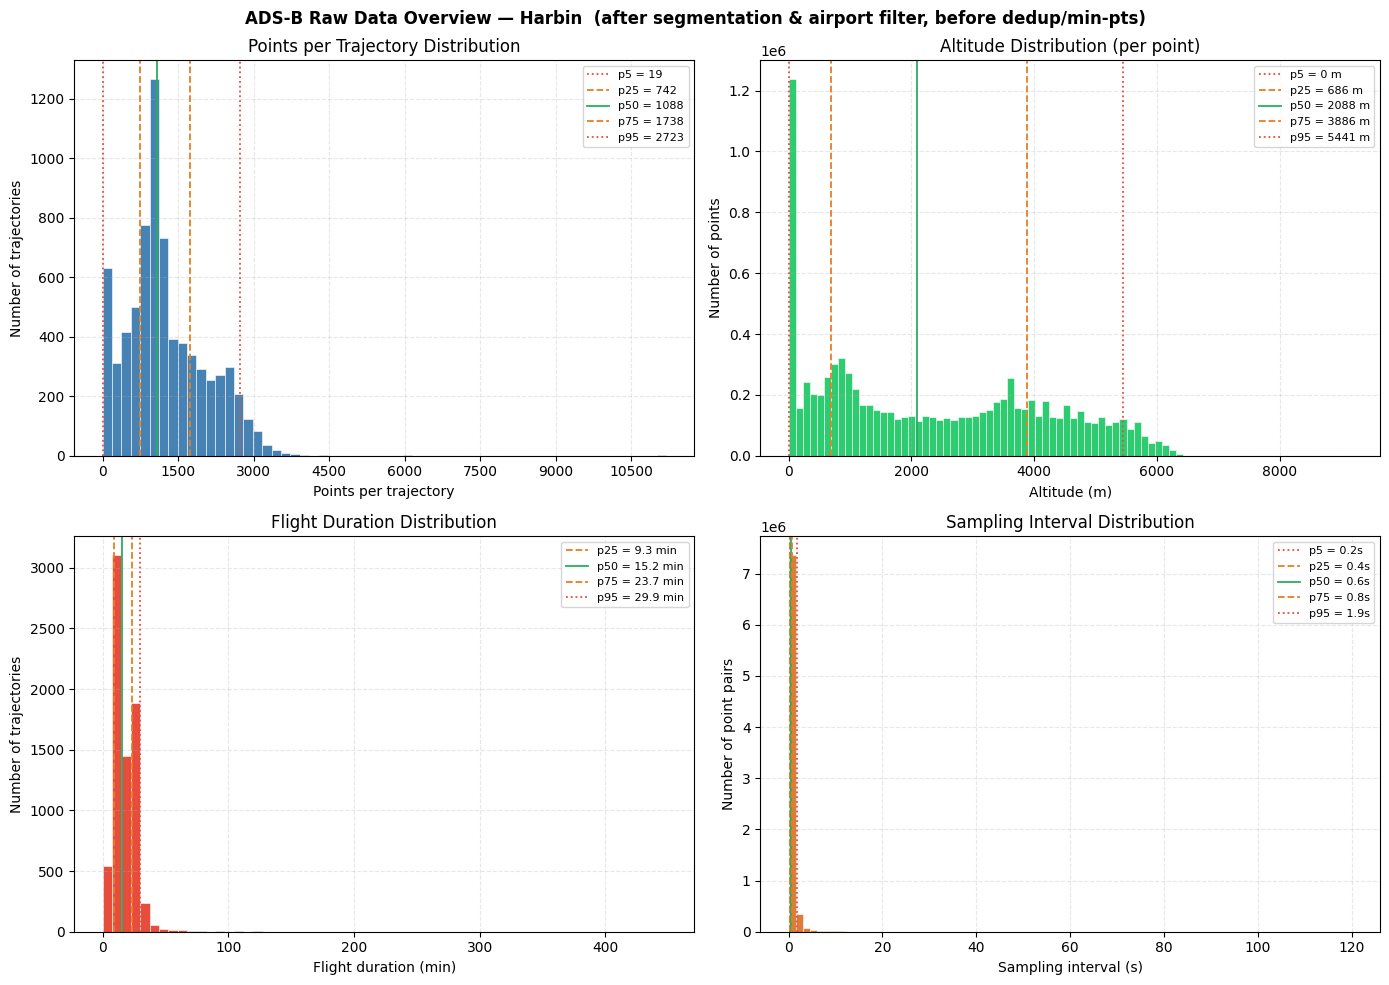

  轨迹总数      : 7,347 条（去重/去短前）
  数据点总数    : 9,177,131 个

  每条轨迹含点数：
    均值 / 标准差 : 1249.1 / 795.5
    最小 / 最大   : 1 / 11184
    p05           : 19 点
    p25           : 742 点
    p50           : 1088 点
    p75           : 1738 点
    p95           : 2723 点

  高度（逐点）：
    范围          : [0, 9174] m
    均值 / 中位数 : 2341 / 2088 m

  飞行时长：
    均值 / 中位数 : 16.8 / 15.2 min
    最短 / 最长   : 0.0 / 448.0 min

  相邻点采样间隔（0 < Δt ≤ 120 s）：
    均值 / 标准差 : 0.87 s / 2.49 s
    p05           : 0.23 s
    p25           : 0.42 s
    p50           : 0.56 s
    p75           : 0.84 s
    p95           : 1.91 s
    > 10 s 占比   : 0.4%


In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "ADS-B Raw Data Overview — Harbin  (after segmentation & airport filter, before dedup/min-pts)",
    fontsize=12, fontweight="bold"
)

_pct_colors = {"p5": "#e74c3c", "p25": "#e67e22", "p50": "#27ae60",
               "p75": "#e67e22", "p95": "#e74c3c"}

# ── 1. 每条轨迹含点数频数分布 ─────────────────────────────────────
ax = axes[0, 0]
_seg_lens = df_raw_segmented.groupby("flight_id")["lng"].count()
ax.hist(_seg_lens.values, bins=60, color="#4682B4", edgecolor="white", linewidth=0.4)
ax.set_xlabel("Points per trajectory")
ax.set_ylabel("Number of trajectories")
ax.set_title("Points per Trajectory Distribution")
for q, ls, lbl in [(0.05, ":", "p5"), (0.25, "--", "p25"), (0.50, "-", "p50"),
                   (0.75, "--", "p75"), (0.95, ":", "p95")]:
    v = float(_seg_lens.quantile(q))
    ax.axvline(v, color=_pct_colors[lbl], linestyle=ls, linewidth=1.3,
               label=f"{lbl} = {v:.0f}")
ax.legend(fontsize=8, framealpha=0.8)
ax.grid(True, alpha=0.3, linestyle="--")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# ── 2. 高度逐点分布 ───────────────────────────────────────────────
ax = axes[0, 1]
_alt_all = df_raw_segmented["altitude"].dropna().values
ax.hist(_alt_all, bins=80, color="#2ecc71", edgecolor="white", linewidth=0.4)
ax.set_xlabel("Altitude (m)")
ax.set_ylabel("Number of points")
ax.set_title("Altitude Distribution (per point)")
for q, ls, lbl in [(0.05, ":", "p5"), (0.25, "--", "p25"), (0.50, "-", "p50"),
                   (0.75, "--", "p75"), (0.95, ":", "p95")]:
    v = float(np.quantile(_alt_all, q))
    ax.axvline(v, color=_pct_colors[lbl], linestyle=ls, linewidth=1.3,
               label=f"{lbl} = {v:.0f} m")
ax.legend(fontsize=8, framealpha=0.8)
ax.grid(True, alpha=0.3, linestyle="--")

# ── 3. 飞行时长分布 ───────────────────────────────────────────────
ax = axes[1, 0]
_dur_min = (
    df_raw_segmented.groupby("flight_id")["position_time"]
    .apply(lambda s: (s.max() - s.min()).total_seconds() / 60)
)
ax.hist(_dur_min.values, bins=60, color="#e74c3c", edgecolor="white", linewidth=0.4)
ax.set_xlabel("Flight duration (min)")
ax.set_ylabel("Number of trajectories")
ax.set_title("Flight Duration Distribution")
for q, ls, lbl in [(0.25, "--", "p25"), (0.50, "-", "p50"),
                   (0.75, "--", "p75"), (0.95, ":", "p95")]:
    v = float(_dur_min.quantile(q))
    ax.axvline(v, color=_pct_colors[lbl], linestyle=ls, linewidth=1.3,
               label=f"{lbl} = {v:.1f} min")
ax.legend(fontsize=8, framealpha=0.8)
ax.grid(True, alpha=0.3, linestyle="--")

# ── 4. 采样时间间隔分布 ──────────────────────────────────────────
ax = axes[1, 1]
_df_s = df_raw_segmented.sort_values(["flight_id", "position_time"])
_dt_series = (
    _df_s.groupby("flight_id")["position_time"]
    .apply(lambda s: s.diff().dt.total_seconds().dropna())
)
try:
    _dt_vals = _dt_series.droplevel(0).values.astype(float)
except Exception:
    _dt_vals = np.concatenate([v.values for v in _dt_series])
_dt_vals = _dt_vals[(_dt_vals > 0) & (_dt_vals <= 120)]
ax.hist(_dt_vals, bins=80, color="#E07B39", edgecolor="white", linewidth=0.4)
ax.set_xlabel("Sampling interval (s)")
ax.set_ylabel("Number of point pairs")
ax.set_title("Sampling Interval Distribution")
for q, ls, lbl in [(0.05, ":", "p5"), (0.25, "--", "p25"), (0.50, "-", "p50"),
                   (0.75, "--", "p75"), (0.95, ":", "p95")]:
    v = float(np.quantile(_dt_vals, q))
    ax.axvline(v, color=_pct_colors[lbl], linestyle=ls, linewidth=1.3,
               label=f"{lbl} = {v:.1f}s")
ax.legend(fontsize=8, framealpha=0.8)
ax.grid(True, alpha=0.3, linestyle="--")

fig.tight_layout()
plt.show()

print("=" * 52)
print(f"  轨迹总数      : {len(_seg_lens):,} 条（去重/去短前）")
print(f"  数据点总数    : {len(df_raw_segmented):,} 个")
print()
print("  每条轨迹含点数：")
print(f"    均值 / 标准差 : {_seg_lens.mean():.1f} / {_seg_lens.std():.1f}")
print(f"    最小 / 最大   : {_seg_lens.min()} / {_seg_lens.max()}")
for q in [0.05, 0.25, 0.50, 0.75, 0.95]:
    print(f"    p{int(q*100):02d}           : {_seg_lens.quantile(q):.0f} 点")
print()
print("  高度（逐点）：")
print(f"    范围          : [{_alt_all.min():.0f}, {_alt_all.max():.0f}] m")
print(f"    均值 / 中位数 : {_alt_all.mean():.0f} / {float(np.median(_alt_all)):.0f} m")
print()
print("  飞行时长：")
print(f"    均值 / 中位数 : {_dur_min.mean():.1f} / {_dur_min.median():.1f} min")
print(f"    最短 / 最长   : {_dur_min.min():.1f} / {_dur_min.max():.1f} min")
print()
print("  相邻点采样间隔（0 < Δt ≤ 120 s）：")
print(f"    均值 / 标准差 : {_dt_vals.mean():.2f} s / {_dt_vals.std():.2f} s")
for q in [0.05, 0.25, 0.50, 0.75, 0.95]:
    print(f"    p{int(q*100):02d}           : {float(np.quantile(_dt_vals, q)):.2f} s")
print(f"    > 10 s 占比   : {(_dt_vals > 10).mean()*100:.1f}%")
print("=" * 52)


In [3]:
# ── Stage 2：去重 + 去短 + 逐日保存 parquet ──────────────────────
_n_before_dedup = len(df_raw_segmented)
df_clean = df_raw_segmented.drop_duplicates(
    subset=["icao", "position_time", "lng", "lat", "altitude"]
).copy()
print(f"去重: {_n_before_dedup:,} → {len(df_clean):,} 行（删除 {_n_before_dedup - len(df_clean):,} 行）")

_seg_len = df_clean.groupby("flight_id")["lng"].count()
_valid_fids = _seg_len.index[_seg_len >= MIN_POINTS]
_n_short = len(_seg_len) - len(_valid_fids)
df_clean = df_clean[df_clean["flight_id"].isin(_valid_fids)].copy()
print(f"去除过短（< {MIN_POINTS} 点）: 删除 {_n_short:,} 条，保留 {df_clean['flight_id'].nunique():,} 条")

# ── 逐日保存 parquet ──────────────────────────────────────────────
daily_parquets = []
for _fp in file_paths:
    _date_str = os.path.splitext(os.path.basename(_fp))[0]
    _out_pq   = os.path.join(OUT_DIR, f"{_date_str}.parquet")
    daily_parquets.append(_out_pq)
    if os.path.exists(_out_pq):
        print(f"  {_date_str}: parquet 已存在，跳过。")
        continue
    _date_key = _date_str.replace("-", "")
    _df_day = df_clean[df_clean["flight_id"].str.contains(_date_key)].copy()
    if len(_df_day) > 0:
        _df_day.to_parquet(_out_pq, index=False)
        print(f"  保存 {_out_pq}  ({_df_day['flight_id'].nunique():,} 条)")
    else:
        print(f"  {_date_str}: 无有效数据")

print(f"\nStage 2 完成，共 {len(daily_parquets)} 个 parquet 文件。")


NameError: name 'df_raw_segmented' is not defined

In [6]:
# ── 逐日轨迹地图（folium），每日一个 HTML ─────────────────────────
import folium
import json as _json

VIZ_DIR = os.path.join(OUT_DIR, "daily_maps_filtered")
os.makedirs(VIZ_DIR, exist_ok=True)

# ── 左侧面板 CSS + Chart.js CDN ──────────────────────────────────
_PANEL_CSS = """
<style>
#traj-panel {
    position: fixed; top: 0; left: 0;
    width: 340px; height: 100vh;
    background: rgba(255,255,255,0.96);
    box-shadow: 2px 0 8px rgba(0,0,0,0.15);
    z-index: 9999;
    transform: translateX(-100%);
    transition: transform 0.3s ease;
    display: flex; flex-direction: column;
    font-family: "Segoe UI", Arial, sans-serif;
}
#traj-panel.open { transform: translateX(0); }
#traj-panel-header {
    padding: 12px 16px; font-size: 14px; font-weight: 600;
    border-bottom: 1px solid #e0e0e0;
    display: flex; justify-content: space-between; align-items: center;
}
#traj-panel-close {
    cursor: pointer; font-size: 18px; color: #888;
    border: none; background: none;
}
#traj-panel-close:hover { color: #333; }
#traj-chart-wrap { padding: 10px; height: 320px; }
</style>
"""

_PANEL_HTML = """
<div id="traj-panel">
  <div id="traj-panel-header">
    <span id="traj-panel-title">轨迹高度</span>
    <button id="traj-panel-close" onclick="closePanel()">&times;</button>
  </div>
  <div id="traj-chart-wrap">
    <canvas id="traj-chart"></canvas>
  </div>
</div>
"""

_CHARTJS_CDN = '<script src="https://cdn.jsdelivr.net/npm/chart.js@4/dist/chart.umd.min.js"></script>'

# ── 点击高亮 + 显示面板的 JS 模板 ─────────────────────────────────
_MAIN_JS_TEMPLATE = """
<script>
var _trajData = __TRAJ_DATA_PLACEHOLDER__;
var _chartInstance = null;

function closePanel() {
    document.getElementById('traj-panel').classList.remove('open');
}

function showAltChart(fid) {
    var panel = document.getElementById('traj-panel');
    document.getElementById('traj-panel-title').textContent = fid;
    panel.classList.add('open');

    var d = _trajData[fid];
    if (!d) { console.warn('No data for', fid); return; }

    if (_chartInstance) _chartInstance.destroy();

    var ctx = document.getElementById('traj-chart').getContext('2d');
    _chartInstance = new Chart(ctx, {
        type: 'line',
        data: {
            labels: d.t,
            datasets: [{
                label: 'Altitude (m)',
                data: d.alt,
                borderColor: '#4682B4',
                backgroundColor: 'rgba(70,130,180,0.15)',
                fill: true,
                pointRadius: 2,
                pointBackgroundColor: '#4682B4',
                borderWidth: 1.5,
                tension: 0.1
            }]
        },
        options: {
            responsive: true,
            maintainAspectRatio: false,
            plugins: {
                legend: { display: false },
                title: { display: true, text: 'Altitude vs Time', font: {size: 13} }
            },
            scales: {
                x: {
                    title: { display: true, text: 'Time' },
                    ticks: { maxTicksLimit: 6, maxRotation: 45, font: {size: 10} }
                },
                y: {
                    title: { display: true, text: 'Altitude (m)' }
                }
            }
        }
    });
}

document.addEventListener('DOMContentLoaded', function() {
    var map = Object.values(window).find(function(v){ return v instanceof L.Map; });
    if (!map) return;
    map.eachLayer(function(layer) {
        if (layer instanceof L.Polyline && !(layer instanceof L.Polygon)) {
            layer._highlighted = false;
            layer.on('click', function(e) {
                var lyr = e.target;
                // reset all
                map.eachLayer(function(l) {
                    if (l instanceof L.Polyline && !(l instanceof L.Polygon) && l._highlighted) {
                        l.setStyle({color: '#4682B4', weight: 1.5, opacity: 0.35});
                        l._highlighted = false;
                    }
                });
                lyr.setStyle({color: '#FF3333', weight: 4, opacity: 0.9});
                lyr.bringToFront();
                lyr._highlighted = true;
                // get flight_id from tooltip (folium wraps in <div>)
                var tip = lyr.getTooltip();
                if (tip) {
                    var raw = tip.getContent();
                    var tmp = document.createElement('div');
                    tmp.innerHTML = raw;
                    var fid = tmp.textContent.trim();
                    showAltChart(fid);
                }
            });
        }
    });
});
</script>
"""

for _pq in daily_parquets:
    if not os.path.exists(_pq):
        continue
    _date = os.path.splitext(os.path.basename(_pq))[0]
    _html = os.path.join(VIZ_DIR, f"map_{_date}.html")
    if os.path.exists(_html):
        print(f"{_date}: HTML already exists, skipping.")
        continue

    _df = pd.read_parquet(_pq)
    _n_traj = _df["flight_id"].nunique()
    print(f"{_date}: {_n_traj:,} trajectories ...")

    # ── 构建每条轨迹的 {time, altitude} 数据供前端图表使用 ──
    _traj_chart_data = {}
    for _fid, _grp in _df.groupby("flight_id"):
        _grp_sorted = _grp.sort_values("position_time")
        _times = pd.to_datetime(_grp_sorted["position_time"])
        _traj_chart_data[_fid] = {
            "t": _times.dt.strftime("%H:%M:%S").tolist(),
            "alt": _grp_sorted["altitude"].tolist(),
        }

    _center_lat = _df["lat"].mean()
    _center_lon = _df["lng"].mean()

    m = folium.Map(
        location=[_center_lat, _center_lon],
        zoom_start=8,
        tiles="CartoDB positron",
    )

    for _fid, _grp in _df.groupby("flight_id"):
        coords = list(zip(_grp["lat"].values, _grp["lng"].values))
        line = folium.PolyLine(
            coords,
            weight=1.5,
            color="#4682B4",
            opacity=0.35,
            tooltip=_fid,
        )
        line.options["bubblingMouseEvents"] = False
        line.add_to(m)

    # ── 注入 CSS / HTML / JS ──
    root = m.get_root()
    root.html.add_child(folium.Element(_PANEL_CSS))
    root.html.add_child(folium.Element(_PANEL_HTML))
    root.html.add_child(folium.Element(_CHARTJS_CDN))

    _js_code = _MAIN_JS_TEMPLATE.replace(
        "__TRAJ_DATA_PLACEHOLDER__",
        _json.dumps(_traj_chart_data, ensure_ascii=False),
    )
    root.html.add_child(folium.Element(_js_code))

    m.save(_html)
    print(f"  -> {_html}")
    del _df, _traj_chart_data, m

print(f"\n完成，HTML 保存在 {VIZ_DIR}/")

2025-07-28: HTML already exists, skipping.
2025-07-29: HTML already exists, skipping.
2025-07-30: HTML already exists, skipping.
2025-07-31: HTML already exists, skipping.
2025-08-01: HTML already exists, skipping.
2025-08-02: HTML already exists, skipping.
2025-08-03: HTML already exists, skipping.
2025-12-15: HTML already exists, skipping.
2025-12-16: HTML already exists, skipping.
2025-12-17: HTML already exists, skipping.
2025-12-18: HTML already exists, skipping.
2025-12-19: HTML already exists, skipping.
2025-12-20: HTML already exists, skipping.
2025-12-21: HTML already exists, skipping.

完成，HTML 保存在 haerbin_output\daily_maps_filtered/


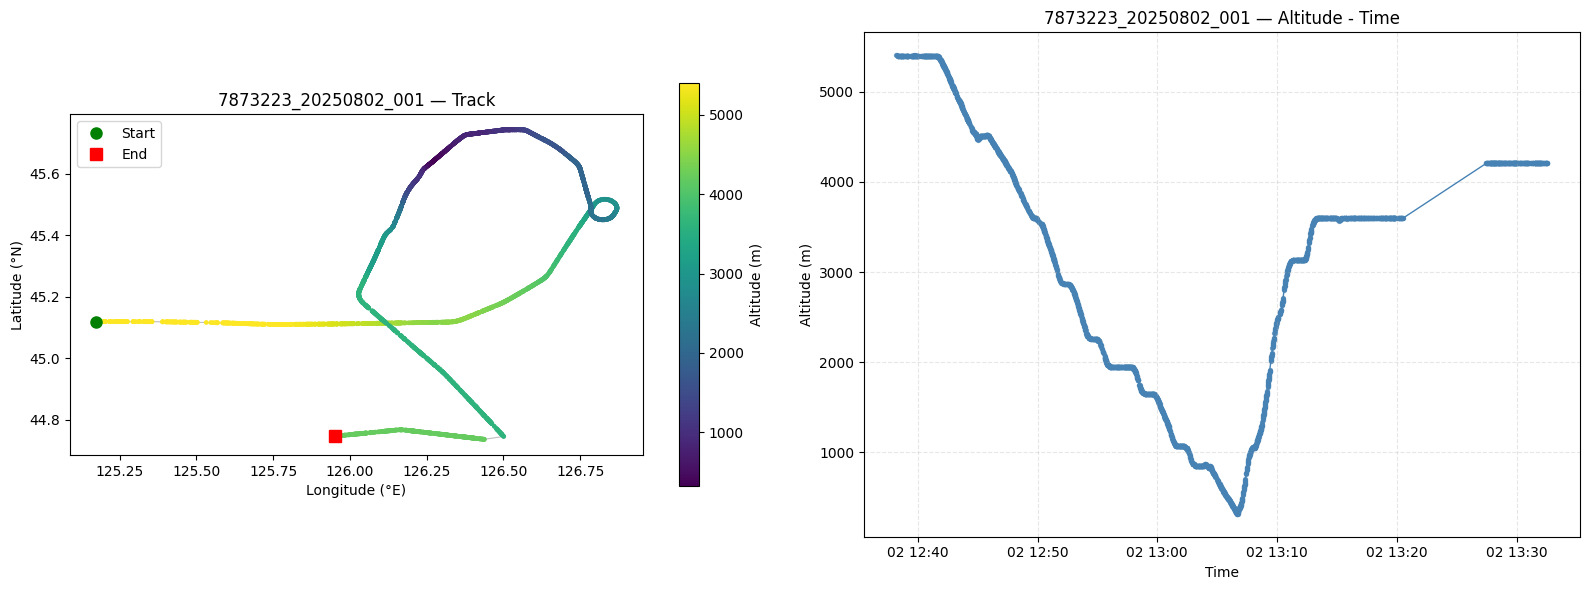

flight_id: 7873223_20250802_001,
Points: 3323,
Alt: [320, 5403] m,
Lng: [125.1733, 126.8693],
Lat: [44.7354, 45.7437]


In [7]:
# ── 指定 flight_id 查看轨迹 + 高度剖面 ──────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

QUERY_FID = "7873223_20250802_001"   # ← 在此修改 flight_id

# 从 parquet 中查找
_query_df = None
for _pq in daily_parquets:
    if not os.path.exists(_pq):
        continue
    _tmp = pd.read_parquet(_pq, filters=[("flight_id", "==", QUERY_FID)])
    if len(_tmp) > 0:
        _query_df = _tmp.sort_values("position_time")
        break

if _query_df is None or len(_query_df) == 0:
    print(f"未找到 flight_id = {QUERY_FID}")
else:
    _t = pd.to_datetime(_query_df["position_time"])
    _lng = _query_df["lng"].values
    _lat = _query_df["lat"].values
    _alt = _query_df["altitude"].values

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # ---- 左图：经纬度平面轨迹 ----
    ax = axes[0]
    sc = ax.scatter(_lng, _lat, c=_alt, cmap="viridis", s=6, zorder=2)
    ax.plot(_lng, _lat, color="gray", linewidth=0.8, alpha=0.5, zorder=1)
    ax.plot(_lng[0], _lat[0], "go", markersize=8, label="Start")
    ax.plot(_lng[-1], _lat[-1], "rs", markersize=8, label="End")
    ax.set_xlabel("Longitude (°E)")
    ax.set_ylabel("Latitude (°N)")
    ax.set_title(f"{QUERY_FID} — Track")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="best")
    fig.colorbar(sc, ax=ax, label="Altitude (m)", shrink=0.8)

    # ---- 右图：高度 ----
    ax2 = axes[1]
    ax2.plot(_t, _alt, color="steelblue", linewidth=1)
    ax2.scatter(_t, _alt, color="steelblue", s=8, alpha=0.7)
    ax2.set_xlabel("Time")
    ax2.set_ylabel("Altitude (m)")
    ax2.set_title(f"{QUERY_FID} — Altitude - Time")
    ax2.grid(True, alpha=0.3, linestyle="--")

    # ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    # ax2.xaxis.set_major_locator(mdates.AutoDateLocator())
    # plt.setp(ax2.get_xticklabels(), rotation=30)

    fig.tight_layout()
    plt.show()
    print(f"flight_id: {QUERY_FID},\n"
          f"Points: {len(_query_df)},\n"
          f"Alt: [{_alt.min():.0f}, {_alt.max():.0f}] m,\n"
          f"Lng: [{_lng.min():.4f}, {_lng.max():.4f}],\n"
          f"Lat: [{_lat.min():.4f}, {_lat.max():.4f}]")
    del _query_df

In [4]:
df_all = pd.concat(
    [pd.read_parquet(p) for p in daily_parquets if os.path.exists(p)],
    ignore_index=True
)

print("合并完成！")
print(f"  总行数     : {len(df_all):,}")
print(f"  航班数     : {df_all['flight_id'].nunique():,}")
print(f"  经度范围   : [{df_all['lng'].min():.3f}, {df_all['lng'].max():.3f}]°E")
print(f"  纬度范围   : [{df_all['lat'].min():.3f}, {df_all['lat'].max():.3f}]°N")
print(f"  高度范围   : [{df_all['altitude'].min():.0f}, {df_all['altitude'].max():.0f}] m")

seg_lens = df_all.groupby("flight_id")["lng"].count()
qs = seg_lens.quantile([.05, .25, .50, .75, .95]).round().astype(int).to_dict()
print(f"\n航班点数分布 (p5/p25/p50/p75/p95):")
print(f"  {qs}")

合并完成！
  总行数     : 8,382,864
  航班数     : 6,913
  经度范围   : [124.947, 127.510]°E
  纬度范围   : [44.724, 46.517]°N
  高度范围   : [0, 8870] m

航班点数分布 (p5/p25/p50/p75/p95):
  {0.05: 272, 0.25: 769, 0.5: 1073, 0.75: 1600, 0.95: 2437}


In [5]:
# ── 地面运行点剖除 ────────────────────────────────────────────────
# 对每条轨迹删除两端的地面滑行段（不删整条轨迹）：
#   · 头部：删去起飞前地面滑行，起点 = 第一个离地点（脱离跑道）
#   · 尾部：删去落地后地面滑行，终点 = 最后空中点之后紧接的第一个触地点
# 高度判断：优先使用 height（AGL），NaN 时用 altitude 补充
import numpy as np

GROUND_HEIGHT_THR = 20   # 米；height/altitude ≤ 此値视为地面运行


def strip_ground_taxi(df_flight, ground_thr=GROUND_HEIGHT_THR):
    """
    去除一条轨迹（按时间排好序）两端的地面滑行段。
    返回裁剪后的 DataFrame；整段均在地面或长度 < 2 则返回 None。
    """
    n = len(df_flight)
    if n == 0:
        return None

    # ── 高度数组：优先 height（AGL），NaN 时以 altitude 填补 ────────────
    if 'height' in df_flight.columns:
        h = df_flight['height'].to_numpy(dtype=float)
        nan_m = np.isnan(h)
        if nan_m.any():
            h[nan_m] = df_flight['altitude'].to_numpy(dtype=float)[nan_m]
    else:
        h = df_flight['altitude'].to_numpy(dtype=float)
    h = np.nan_to_num(h, nan=0.0)

    airborne = h > ground_thr          # True = 空中（非地面运行）

    if not airborne.any():
        return None                    # 整段均在地面 → 丢弃

    first_air = int(np.argmax(airborne))                  # 第一个空中点（脱离跑道）
    last_air  = int(n - 1 - np.argmax(airborne[::-1]))    # 最后一个空中点

    # 终点：最后空中点后的首个地面点（触地）；若无则以最后空中点收尾
    end = last_air + 1 if (last_air + 1 < n) else last_air

    trimmed = df_flight.iloc[first_air : end + 1]
    return trimmed if len(trimmed) >= 2 else None


# ── 应用到 df_all ──────────────────────────────────────────
df_all = df_all.sort_values(['flight_id', 'position_time'])

n_pts_before  = len(df_all)
n_traj_before = df_all['flight_id'].nunique()

parts = []
for fid, grp in df_all.groupby('flight_id', sort=False):
    r = strip_ground_taxi(grp)
    if r is not None and len(r) >= MIN_POINTS:
        parts.append(r)

df_all = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame(columns=df_all.columns)

n_pts_after  = len(df_all)
n_traj_after = df_all['flight_id'].nunique()

print(f'地面滑行点剖除完成：')
print(f'  数据点：{n_pts_before:,} → {n_pts_after:,}  （删除 {n_pts_before - n_pts_after:,} 个）')
print(f'  轨迹数：{n_traj_before:,} → {n_traj_after:,}  （剖除 {n_traj_before - n_traj_after:,} 条点数不足轨迹）')
print(f'  地面阈値：height/altitude ≤ {GROUND_HEIGHT_THR} m')
if df_all['flight_id'].nunique() > 0:
    print(f'  剩余高度范围：[{df_all["altitude"].min():.0f}, {df_all["altitude"].max():.0f}] m')


地面滑行点剖除完成：
  数据点：8,382,864 → 7,271,992  （删除 1,110,872 个）
  轨迹数：6,913 → 6,522  （剖除 391 条点数不足轨迹）
  地面阈値：height/altitude ≤ 20 m
  剩余高度范围：[0, 8870] m


In [6]:
# ── Section 2.5  轨迹跳变检测与过滤 ─────────────────────────────────
import numpy as np

JUMP_KM   = 1.0   # km，连续点间距阈値
MAX_JUMPS = 0     # 允许的最大跳变次数（超过则整段轨迹剖除）


def count_jumps_vec(group, jump_km=JUMP_KM):
    """向量化 Haversine 计算一条轨迹的跳变次数。"""
    lat = group["lat"].values
    lon = group["lng"].values
    if len(lat) < 2:
        return 0
    R    = 6371.0
    lat1 = np.radians(lat[:-1]);  lat2 = np.radians(lat[1:])
    lon1 = np.radians(lon[:-1]);  lon2 = np.radians(lon[1:])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a    = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    dist = 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))
    return int((dist > jump_km).sum())


df_all = df_all.sort_values(["flight_id", "position_time"])

n_before = df_all["flight_id"].nunique()
print(f"跳变检测参数：距离阈値 = {JUMP_KM} km，最大允许跳变次数 = {MAX_JUMPS}")
print(f"过滤前：{n_before:,} 条轨迹，{len(df_all):,} 个数据点")

# 计算每条轨迹的跳变次数
jump_counts = (
    df_all.groupby("flight_id", sort=False)
    .apply(count_jumps_vec)
    .rename("n_jumps")
)

# 分布统计
jump_dist = jump_counts.value_counts().sort_index()
print("跳变数分布（前 10 档）：")
print(jump_dist.head(10).to_string())

n_bad  = int((jump_counts > MAX_JUMPS).sum())
n_good = int((jump_counts <= MAX_JUMPS).sum())
print(f"跳变数 > {MAX_JUMPS}：{n_bad:,} 条轨迹  → 剖除")
print(f"跳变数 ≤ {MAX_JUMPS}：{n_good:,} 条轨迹 → 保留")

# 过滤
valid_ids = jump_counts.index[jump_counts <= MAX_JUMPS]
df_all    = df_all[df_all["flight_id"].isin(valid_ids)].copy()

n_after = df_all["flight_id"].nunique()
print(f"过滤后：{n_after:,} 条轨迹，{len(df_all):,} 个数据点")
print(f"保留率：{n_after / n_before * 100:.1f}%  |  剖除率：{n_bad / n_before * 100:.1f}%")


跳变检测参数：距离阈値 = 1.0 km，最大允许跳变次数 = 0
过滤前：6,522 条轨迹，7,271,992 个数据点


C:\Users\93176\AppData\Local\Temp\ipykernel_44108\895505894.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(count_jumps_vec)


跳变数分布（前 10 档）：
n_jumps
0    2482
1     523
2     396
3     332
4     318
5     261
6     227
7     223
8     216
9     175
跳变数 > 0：4,040 条轨迹  → 剖除
跳变数 ≤ 0：2,482 条轨迹 → 保留
过滤后：2,482 条轨迹，3,069,287 个数据点
保留率：38.1%  |  剖除率：61.9%


In [7]:
# 重采样至T
# 两次归一化，第一次缩至[0,1]，第二次standardscaler
from scipy.interpolate import interp1d as _interp1d
from sklearn.preprocessing import StandardScaler  # ← 改为 StandardScaler
import joblib

METADATA_CSV = os.path.join(OUT_DIR, "haerbin_metadata.csv")

def resample_traj(group, flight_id, T=100, alpha=0.15):
    """
    曲率自适应重采样：转弯段分配更多点，平直段分配更少点。
    alpha : 平直段最低权重比例（0<alpha<=1，越小越激进；1 退化为均匀采样）
    """
    lng = group["lng"].values
    lat = group["lat"].values
    n = len(lng)
    if n < 2:
        return None

    # ── 1. 弧长参数化（经度差用 cos(lat) 修正近似等距性） ──────────
    cos_lat = np.cos(np.radians(lat.mean()))
    dx = np.diff(lng) * cos_lat
    dy = np.diff(lat)
    seg_len = np.hypot(dx, dy)
    seg_len = np.maximum(seg_len, 1e-12)
    arc = np.concatenate([[0.0], np.cumsum(seg_len)])
    arc_norm = arc / arc[-1]            # 归一化弧长参数 s ∈ [0,1]

    # ── 2. 离散曲率：相邻航段航向差（弧度） ──────────────────────────
    headings = np.arctan2(dy, dx)       # 各段航向，shape (n-1,)
    kappa = np.zeros(n)
    if n >= 3:
        dh = np.abs(np.diff(headings))
        dh = np.minimum(dh, 2 * np.pi - dh)   # 折叠到 [0, π]
        kappa[1:-1] = dh                        # 端点曲率为 0

    # ── 3. 采样密度 = alpha + (1-alpha) * kappa_归一化 ───────────────
    kmax = kappa.max()
    kappa_n = kappa / kmax if kmax > 0 else kappa
    weight = alpha + (1.0 - alpha) * kappa_n   # shape (n,)

    # ── 4. 沿弧长积分密度 → CDF ───────────────────────────────────────
    seg_area = (weight[:-1] + weight[1:]) / 2.0 * np.diff(arc_norm)
    cdf = np.concatenate([[0.0], np.cumsum(seg_area)])
    cdf /= cdf[-1]                      # 归一化到 [0,1]

    # ── 5. 均匀采 T 个 CDF 值 → 反查非均匀弧长位置 ───────────────────
    t_arc = np.interp(np.linspace(0, 1, T), cdf, arc_norm)

    # ── 6. 在弧长坐标上插值 lng / lat ─────────────────────────────────
    lng_r = _interp1d(arc_norm, lng)(t_arc)
    lat_r = _interp1d(arc_norm, lat)(t_arc)
    return pd.DataFrame({"flight_id": flight_id, "x": lng_r, "y": lat_r})

need_resample = not os.path.exists(RESAMPLED_CSV)
need_metadata = not os.path.exists(METADATA_CSV)

if not need_resample and not need_metadata:
    print("Both files exist, skipping. Delete to re-run.")
else:
    df_sorted = df_all.sort_values(["flight_id", "position_time"])

    # ---- 1. resample x/y for AE training ---------------------------------
    if need_resample:
        print(f"Resampling {df_all['flight_id'].nunique():,} trajectories to T={T} ...")
        parts = [
            r for fid, grp in df_sorted.groupby("flight_id")
            if (r := resample_traj(grp, fid, T)) is not None
        ]
        df_res = pd.concat(parts, ignore_index=True)
        valid_fids = set(df_res["flight_id"].unique())
        print(f"Resampled: {len(valid_fids):,} trajectories")

        print(f"\nActual lon (0.1%-99.9%): [{df_res['x'].quantile(.001):.3f}, "
              f"{df_res['x'].quantile(.999):.3f}]")
        print(f"Actual lat (0.1%-99.9%): [{df_res['y'].quantile(.001):.3f}, "
              f"{df_res['y'].quantile(.999):.3f}]")

        # ── 第一次归一化：max_range 缩放到 [0,1]，保留宽高比 ──────────
        x_min, x_max = df_res['x'].min(), df_res['x'].max()
        y_min, y_max = df_res['y'].min(), df_res['y'].max()
        x_range = x_max - x_min
        y_range = y_max - y_min
        max_range = max(x_range, y_range)

        print(f"\nGlobal X range: [{x_min:.6f}, {x_max:.6f}] -> {x_range:.6f}")
        print(f"Global Y range: [{y_min:.6f}, {y_max:.6f}] -> {y_range:.6f}")
        print(f"Using max_range: {max_range:.6f} for scaling")

        df_res['x'] = (df_res['x'] - x_min) / max_range  # ← 存入CSV的是[0,1]坐标
        df_res['y'] = (df_res['y'] - y_min) / max_range

        # 保存 max_range 参数，供后续反变换使用
        joblib.dump({'x_min': x_min, 'y_min': y_min, 'max_range': max_range},
                    os.path.join(OUT_DIR, 'geo_scaler_params.joblib'))
        print(f"Geo params saved -> geo_scaler_params.joblib")

        # ── 第二次归一化：StandardScaler 拟合已归一化的数据 ───────────
        df_res["_rank"] = df_res.groupby("flight_id").cumcount()
        xw = df_res.pivot(index="flight_id", columns="_rank", values="x")
        yw = df_res.pivot(index="flight_id", columns="_rank", values="y")
        ok = xw.notna().all(axis=1) & yw.notna().all(axis=1)
        X  = np.concatenate([xw[ok].to_numpy(np.float32),
                              yw[ok].to_numpy(np.float32)], axis=1)
        scaler = StandardScaler()  # ← 改为 StandardScaler
        scaler.fit(X)
        joblib.dump(scaler, SCALER_PATH)
        print(f"Scaler saved -> {SCALER_PATH}")

        df_res.drop(columns=["_rank"]).to_csv(RESAMPLED_CSV, index=False)
        print(f"Resampled CSV saved -> {RESAMPLED_CSV}")
        del df_res, xw, yw, X
    else:
        valid_fids = set(pd.read_csv(RESAMPLED_CSV, usecols=["flight_id"])["flight_id"].unique())
        print(f"Resampled CSV already exists ({len(valid_fids):,} flights), skipping resample.")

    # ---- 2. per-trajectory metadata (aggregate extra columns) ------------
    if need_metadata:
        extra_cols = ["speed", "ver_speed", "callsign", "height", "heading", "ver_speed_type"]
        present    = [c for c in extra_cols if c in df_sorted.columns]

        df_valid = df_sorted[df_sorted["flight_id"].isin(valid_fids)]

        agg_spec = {"icao": ("icao", "first")}
        if "callsign"       in present: agg_spec["callsign"]       = ("callsign",       "first")
        if "ver_speed_type" in present: agg_spec["ver_speed_type"] = ("ver_speed_type",
                                            lambda s: s.mode().iloc[0] if len(s.dropna()) else np.nan)
        if "speed"          in present:
            agg_spec["speed_mean"] = ("speed", "mean")
            agg_spec["speed_max"]  = ("speed", "max")
        if "ver_speed"      in present: agg_spec["ver_speed_mean"] = ("ver_speed", "mean")
        if "height"         in present: agg_spec["height_mean"]    = ("height",    "mean")
        if "heading"        in present: agg_spec["heading_mean"]   = ("heading",   "mean")
        agg_spec["n_points"]   = ("lng",           "count")
        agg_spec["start_time"] = ("position_time", "first")
        agg_spec["end_time"]   = ("position_time", "last")

        meta = df_valid.groupby("flight_id").agg(
            **{alias: pd.NamedAgg(column=col, aggfunc=fn)
               for alias, (col, fn) in agg_spec.items()}
        ).reset_index()
        meta["duration_min"] = (
            (meta["end_time"] - meta["start_time"]).dt.total_seconds() / 60
        )
        meta.to_csv(METADATA_CSV, index=False)
        print(f"Metadata CSV saved -> {METADATA_CSV}  ({len(meta):,} rows)")
        print(meta.head(3).to_string())
        del df_valid, meta
    else:
        print(f"Metadata CSV already exists, skipping.")

    del df_sorted, df_all

Both files exist, skipping. Delete to re-run.


Loaded 2,482 trajectories for visualisation


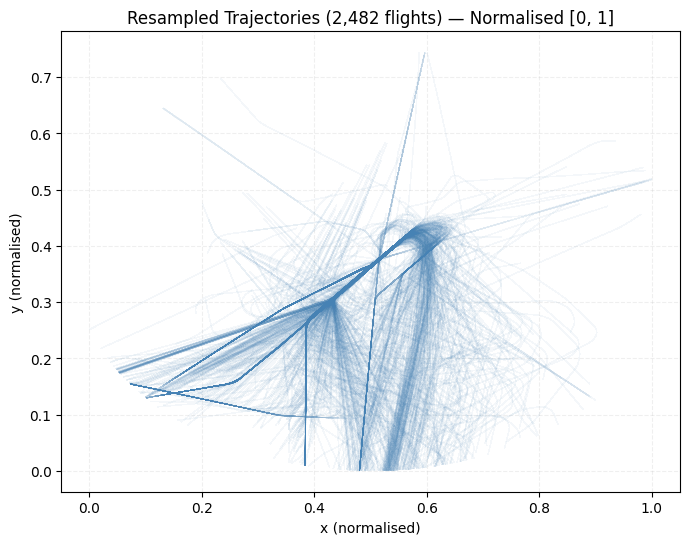

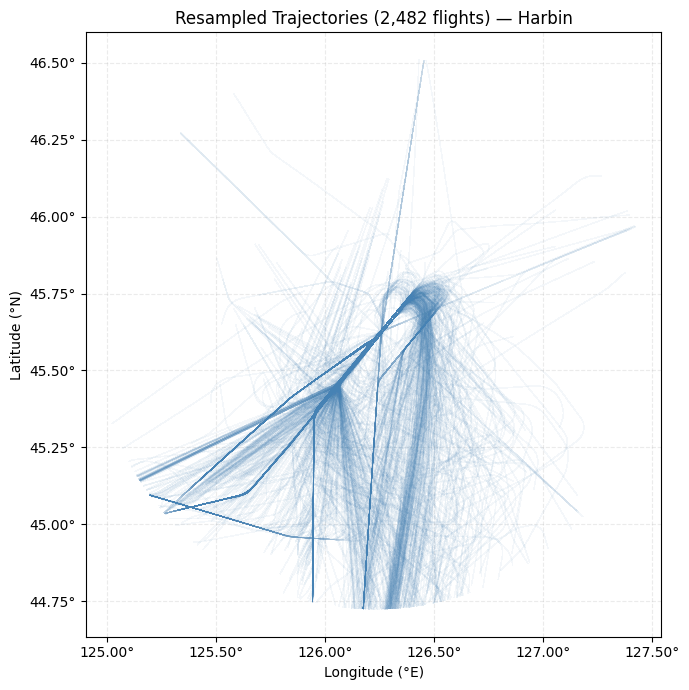

In [8]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import matplotlib.ticker as _mtk
import joblib as _jbl

# Load resampled data ([0,1] normalised coordinates)
_df_viz = pd.read_csv(RESAMPLED_CSV)
_sc_viz = _jbl.load(SCALER_PATH)

# Per-trajectory arrays in [0,1] space
_raw_segs = {fid: grp[["x", "y"]].values
             for fid, grp in _df_viz.groupby("flight_id")}
raw_lines = [arr for arr in _raw_segs.values() if len(arr) == T]
n_flights  = len(raw_lines)
print(f"Loaded {n_flights:,} trajectories for visualisation")

# ---- Plot 1: [0,1] normalised coordinates (as stored in CSV) ----
_fig, _ax = plt.subplots(figsize=(7, 7))
_lc = LineCollection(raw_lines, linewidths=0.4, alpha=0.06,
                     antialiased=False, colors='steelblue')
_ax.add_collection(_lc); _ax.autoscale(); _ax.set_aspect('equal', adjustable='box')
_ax.set_title(f'Resampled Trajectories ({n_flights:,} flights) — Normalised [0, 1]')
_ax.set_xlabel('x (normalised)'); _ax.set_ylabel('y (normalised)')
_ax.grid(True, alpha=0.2, linestyle='--')
_fig.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'viz_all_normalised.png'), dpi=150, bbox_inches='tight')
plt.show()

# ---- Plot 2: geographic coordinates (inverse [0,1] -> lng/lat) ----
_geo_params = _jbl.load(os.path.join(OUT_DIR, 'geo_scaler_params.joblib'))
_x_min  = _geo_params['x_min']
_y_min  = _geo_params['y_min']
_mxr    = _geo_params['max_range']

_geo_lines = [
    np.column_stack([seg[:, 0] * _mxr + _x_min,
                     seg[:, 1] * _mxr + _y_min])
    for seg in raw_lines
]

_fig2, _ax2 = plt.subplots(figsize=(7, 7))
_lc2 = LineCollection(_geo_lines, linewidths=0.4, alpha=0.06,
                      antialiased=False, colors='steelblue')
_ax2.add_collection(_lc2); _ax2.autoscale(); _ax2.set_aspect('auto')
_ax2.xaxis.set_major_formatter(_mtk.FormatStrFormatter('%.2f°'))
_ax2.yaxis.set_major_formatter(_mtk.FormatStrFormatter('%.2f°'))
_ax2.set_title(f'Resampled Trajectories ({n_flights:,} flights) — Harbin')
_ax2.set_xlabel('Longitude (°E)'); _ax2.set_ylabel('Latitude (°N)')
_ax2.grid(True, alpha=0.25, linestyle='--')
_fig2.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'viz_all_geographic.png'), dpi=150, bbox_inches='tight')
plt.show()

del _df_viz, _raw_segs


In [9]:
import sys
sys.path.insert(0, "e:/infovis")   # directory containing ae_utils.py
from ae_utils import train_fc_ae, train_lstm_ae, train_gru_ae

# ---- FC-AE ---------------------------------------------------------------
if os.path.exists(FC_MODEL_PATH):
    print(f"Found {FC_MODEL_PATH} -- skipping FC-AE training.")
else:
    train_fc_ae(
        resampled_csv = RESAMPLED_CSV,
        scaler_path   = SCALER_PATH,
        model_out     = FC_MODEL_PATH,
        T             = T,
        latent_dim    = 32,
        lr            = 1e-3,
        epochs        = 200,
        batch_size    = 32,
        print_every   = 20,
    )

# ---- LSTM-AE -------------------------------------------------------------
if os.path.exists(LSTM_MODEL_PATH):
    print(f"Found {LSTM_MODEL_PATH} -- skipping LSTM-AE training.")
else:
    train_lstm_ae(
        resampled_csv = RESAMPLED_CSV,
        scaler_path   = SCALER_PATH,
        model_out     = LSTM_MODEL_PATH,
        T             = T,
        latent_dim    = 32,
        enc_hidden    = 128,
        dec_hidden    = 128,
        n_layers      = 2,
        dropout       = 0.1,
        lr            = 1e-3,
        epochs        = 200,
        batch_size    = 32,
        print_every   = 20,
    )

# ---- GRU-AE --------------------------------------------------------------
if os.path.exists(GRU_MODEL_PATH):
    print(f"Found {GRU_MODEL_PATH} -- skipping GRU-AE training.")
else:
    train_gru_ae(
        resampled_csv = RESAMPLED_CSV,
        scaler_path   = SCALER_PATH,
        model_out     = GRU_MODEL_PATH,
        T             = T,
        latent_dim    = 32,
        enc_hidden    = 128,
        dec_hidden    = 128,
        n_layers      = 2,
        dropout       = 0.1,
        lr            = 1e-3,
        epochs        = 200,
        batch_size    = 32,
        print_every   = 20,
    )

Found haerbin_output\haerbin_fc_ae.pth -- skipping FC-AE training.
Found haerbin_output\haerbin_lstm_ae.pth -- skipping LSTM-AE training.
Found haerbin_output\haerbin_gru_ae.pth -- skipping GRU-AE training.


In [10]:
import torch, gc
import sys; sys.path.insert(0, "e:/infovis")
from ae_utils import TrajectoryAutoencoder, TrajectoryGRUAE
import joblib as _jbl2
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import matplotlib.ticker as _mtk2

N_BASELINE = 100

GEO_PARAMS_PATH = os.path.join(OUT_DIR, "geo_scaler_params.joblib")

def _to_geo(arr_01, x_min, y_min, max_range, T):
    """Convert [0,1]-space array (N, 2T) back to geographic (lng, lat)."""
    lng = arr_01[:, :T] * max_range + x_min
    lat = arr_01[:, T:] * max_range + y_min
    return lng, lat

def _viz_baseline(model, model_label, color, raw_b, X_sc_b, sc_b, geo_params, T, out_dir):
    """Reconstruct with model, pick best-N, plot 2x2:
      (0,0) [0,1]-space original    (0,1) Geographic original
      (1,0) [0,1]-space recon       (1,1) Geographic recon
    Left column shares axes (normalised space); right column shares axes (geo space).
    """
    x_min     = geo_params["x_min"]
    y_min     = geo_params["y_min"]
    max_range = geo_params["max_range"]

    model.eval()
    with torch.no_grad():
        _device = next(model.parameters()).device
        _Xr_sc  = model(torch.from_numpy(X_sc_b).to(_device)).cpu().numpy()

    # inverse 2nd norm (StandardScaler) -> [0,1] space
    _Xr_01  = sc_b.inverse_transform(_Xr_sc)

    # select best-N by RMSE in [0,1] space
    _dx   = _Xr_01[:, :T] - raw_b[:, :T]
    _dy   = _Xr_01[:, T:] - raw_b[:, T:]
    _rmse = np.sqrt((_dx ** 2 + _dy ** 2).mean(axis=1))
    _best = np.argsort(_rmse)[:N_BASELINE]
    print(f"{model_label} best-{N_BASELINE} RMSE (01-space): [{_rmse[_best].min():.5f}, {_rmse[_best].max():.5f}]")

    # [0,1]-space segments for left column
    _best_norm  = [np.column_stack([raw_b[i, :T],   raw_b[i, T:]])   for i in _best]
    _best_norm_recon = [np.column_stack([_Xr_01[i, :T], _Xr_01[i, T:]]) for i in _best]

    # inverse 1st norm (max_range) -> geographic
    _orig_lng,  _orig_lat  = _to_geo(raw_b,    x_min, y_min, max_range, T)
    _recon_lng, _recon_lat = _to_geo(_Xr_01,   x_min, y_min, max_range, T)
    _best_geo      = [np.column_stack([_orig_lng[i],  _orig_lat[i]])  for i in _best]
    _best_geo_recon = [np.column_stack([_recon_lng[i], _recon_lat[i]]) for i in _best]

    # ---- 2x2 figure ----
    _fig, _axes = plt.subplots(2, 2, figsize=(18, 14),
                               sharex="col", sharey="col")
    _fig.suptitle(f"{model_label} Baseline — Top {N_BASELINE}", fontsize=14)

    _geo_fmt = _mtk2.FormatStrFormatter("%.2f")

    def _add_lc(ax, segs, lw=0.8, alpha=0.25):
        lc = LineCollection(segs, linewidths=lw, alpha=alpha,
                            antialiased=False, colors=color)
        ax.add_collection(lc)
        ax.autoscale()

    # (0,0) [0,1] original
    _add_lc(_axes[0, 0], _best_norm)
    _axes[0, 0].set_title("Normalised [0,1] (Original)")
    _axes[0, 0].set_xlabel("x (0-1)"); _axes[0, 0].set_ylabel("y (0-1)")
    _axes[0, 0].set_aspect("equal", adjustable="box")
    _axes[0, 0].grid(False)

    # (1,0) [0,1] reconstructed
    _add_lc(_axes[1, 0], _best_norm_recon)
    _axes[1, 0].set_title("Normalised [0,1] (Reconstructed)")
    _axes[1, 0].set_xlabel("x (0-1)"); _axes[1, 0].set_ylabel("y (0-1)")
    _axes[1, 0].set_aspect("equal", adjustable="box")
    _axes[1, 0].grid(False)

    # (0,1) geographic original
    _add_lc(_axes[0, 1], _best_geo)
    _axes[0, 1].set_title("Geographic (Original)")
    _axes[0, 1].set_xlabel("Longitude (E)"); _axes[0, 1].set_ylabel("Latitude (N)")
    _axes[0, 1].xaxis.set_major_formatter(_geo_fmt)
    _axes[0, 1].yaxis.set_major_formatter(_geo_fmt)
    _axes[0, 1].grid(True, alpha=0.25, linestyle="--")

    # (1,1) geographic reconstructed
    _add_lc(_axes[1, 1], _best_geo_recon)
    _axes[1, 1].set_title("Geographic (Reconstructed)")
    _axes[1, 1].set_xlabel("Longitude (E)"); _axes[1, 1].set_ylabel("Latitude (N)")
    _axes[1, 1].xaxis.set_major_formatter(_geo_fmt)
    _axes[1, 1].yaxis.set_major_formatter(_geo_fmt)
    _axes[1, 1].grid(True, alpha=0.25, linestyle="--")

    _fig.tight_layout()
    _fname = os.path.join(out_dir, f"viz_baseline_{model_label.lower().replace('-','_')}_2x2.png")
    plt.savefig(_fname, dpi=150, bbox_inches="tight")
    plt.show()

# ---- load shared data once -----------------------------------------------
_df_b   = pd.read_csv(RESAMPLED_CSV)
_sc_b   = _jbl2.load(SCALER_PATH)
_geo_params = _jbl2.load(GEO_PARAMS_PATH)
_segs_b = {fid: grp[["x", "y"]].values for fid, grp in _df_b.groupby("flight_id")}
_b_lines = [arr for arr in _segs_b.values() if len(arr) == T]
# raw_b: [0,1] space (first norm applied, StandardScaler not yet applied)
_raw_b   = np.array([np.concatenate([seg[:, 0], seg[:, 1]]) for seg in _b_lines], dtype=np.float32)
_X_sc_b  = _sc_b.transform(_raw_b).astype(np.float32)
del _df_b, _segs_b
print(f"Loaded {len(_b_lines):,} trajectories from {RESAMPLED_CSV}")
print(f"Geo params: x_min={_geo_params['x_min']:.4f}, y_min={_geo_params['y_min']:.4f}, max_range={_geo_params['max_range']:.4f}")

_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {_device}")


Loaded 2,482 trajectories from haerbin_output\haerbin_resampled.csv
Geo params: x_min=125.0227, y_min=44.7237, max_range=2.4014
Device: cuda


共加载 2,482 条轨迹


C:\Users\93176\AppData\Local\Temp\ipykernel_35184\3051092242.py:49: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  _mdl.load_state_dict(torch.load(_path, map_location=_device

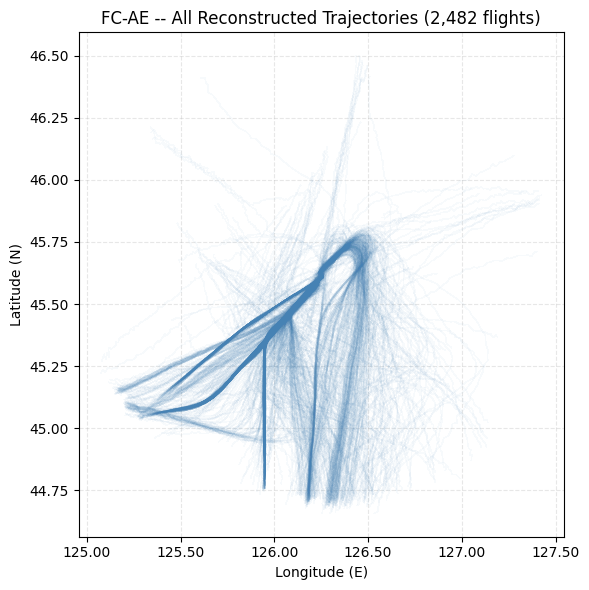

Saved -> haerbin_output\viz_all_recon_fc_ae.png


e:\infovis\ae_utils.py:366: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(model_path, map_location=device)


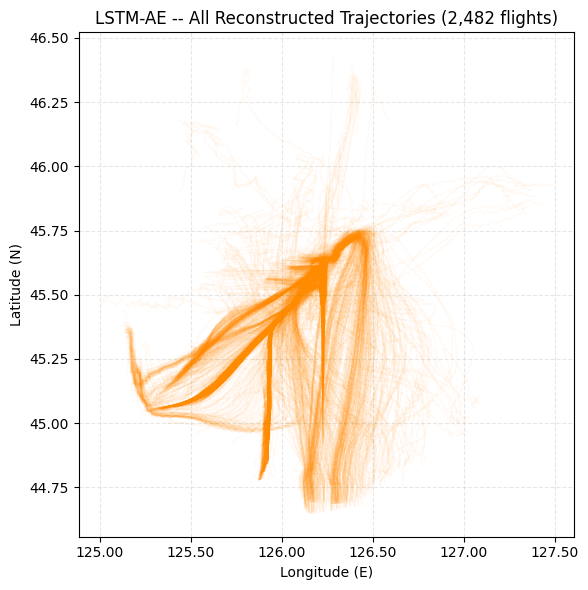

Saved -> haerbin_output\viz_all_recon_lstm_ae.png


e:\infovis\ae_utils.py:377: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(model_path, map_location=device)


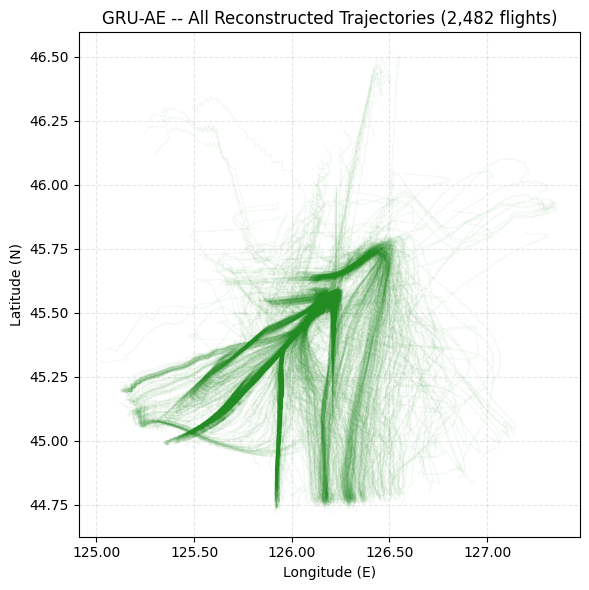

Saved -> haerbin_output\viz_all_recon_gru_ae.png
所有轨迹重构可视化完成。


In [35]:
# -- All-trajectory Reconstruction Visualisation (FC-AE / LSTM-AE / GRU-AE) --
import torch, gc
import sys; sys.path.insert(0, 'e:/infovis')
from ae_utils import TrajectoryAutoencoder as _FCAE3, _load_lstm_ae as _load_lstm3, _load_gru_ae as _load_gru3
import joblib as _jbl_ar
from matplotlib.collections import LineCollection
import matplotlib.ticker as _mtk_ar

_device_ar = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

_df_ar   = pd.read_csv(RESAMPLED_CSV)
_sc_ar   = _jbl_ar.load(SCALER_PATH)
_geo_ar  = _jbl_ar.load(GEO_PARAMS_PATH)
_xmin_ar = _geo_ar['x_min']
_ymin_ar = _geo_ar['y_min']
_mr_ar   = _geo_ar['max_range']

_segs_ar  = {fid: grp[['x','y']].values for fid, grp in _df_ar.groupby('flight_id')}
_lines_ar = [arr for arr in _segs_ar.values() if len(arr) == T]
_raw_ar   = np.array([np.concatenate([seg[:,0], seg[:,1]]) for seg in _lines_ar], dtype=np.float32)
_X_sc_ar  = _sc_ar.transform(_raw_ar).astype(np.float32)
_Xt_ar    = torch.from_numpy(_X_sc_ar).to(_device_ar)
print(f'共加载 {len(_lines_ar):,} 条轨迹')

def _all_recon_geo(model, Xt, sc, x_min, y_min, max_range, T, batch=512):
    model.eval()
    parts = []
    with torch.no_grad():
        for i in range(0, len(Xt), batch):
            parts.append(model(Xt[i:i+batch]).cpu().numpy())
    Xr_sc = np.vstack(parts)
    Xr_01 = sc.inverse_transform(Xr_sc)
    lng = Xr_01[:, :T] * max_range + x_min
    lat = Xr_01[:, T:] * max_range + y_min
    return [np.column_stack([lng[i], lat[i]]) for i in range(len(lng))]

_models_ar = [
    ('FC-AE',   FC_MODEL_PATH,   'steelblue'),
    ('LSTM-AE', LSTM_MODEL_PATH, 'darkorange'),
    ('GRU-AE',  GRU_MODEL_PATH,  'forestgreen'),
]

for _lbl, _path, _clr in _models_ar:
    if not os.path.exists(_path):
        print(f'Skipping {_lbl}: model not found')
        continue
    if _lbl == 'FC-AE':
        _mdl = _FCAE3(2 * T, 32).to(_device_ar)
        _mdl.load_state_dict(torch.load(_path, map_location=_device_ar))
    elif _lbl == 'LSTM-AE':
        _mdl, _ = _load_lstm3(_path, _device_ar)
    else:
        _mdl, _ = _load_gru3(_path, _device_ar)

    _recon_segs = _all_recon_geo(_mdl, _Xt_ar, _sc_ar, _xmin_ar, _ymin_ar, _mr_ar, T)
    del _mdl; torch.cuda.empty_cache(); gc.collect()

    _fig_ar, _ax_ar = plt.subplots(figsize=(6, 6))
    _lc_ar = LineCollection(_recon_segs, linewidths=0.4, alpha=0.04,
                            antialiased=False, colors=_clr)
    _ax_ar.add_collection(_lc_ar)
    _ax_ar.autoscale()
    _ax_ar.xaxis.set_major_formatter(_mtk_ar.FormatStrFormatter('%.2f'))
    _ax_ar.yaxis.set_major_formatter(_mtk_ar.FormatStrFormatter('%.2f'))
    _ax_ar.set_title(f'{_lbl} -- All Reconstructed Trajectories ({len(_recon_segs):,} flights)')
    _ax_ar.set_xlabel('Longitude (E)')
    _ax_ar.set_ylabel('Latitude (N)')
    _ax_ar.grid(True, alpha=0.3, linestyle='--')
    _fig_ar.tight_layout()
    _fname_ar = os.path.join(OUT_DIR, f'viz_all_recon_{_lbl.lower().replace("-","_")}.png')
    plt.savefig(_fname_ar, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved -> {_fname_ar}')

del _Xt_ar, _raw_ar, _X_sc_ar, _lines_ar, _segs_ar, _df_ar
gc.collect()
print('所有轨迹重构可视化完成。')


FC-AE best-100 RMSE (01-space): [0.00119, 0.00197]


C:\Users\93176\AppData\Local\Temp\ipykernel_35184\3103037130.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  _fc.load_state_dict(torch.load(FC_MODEL_PATH, map_location=_

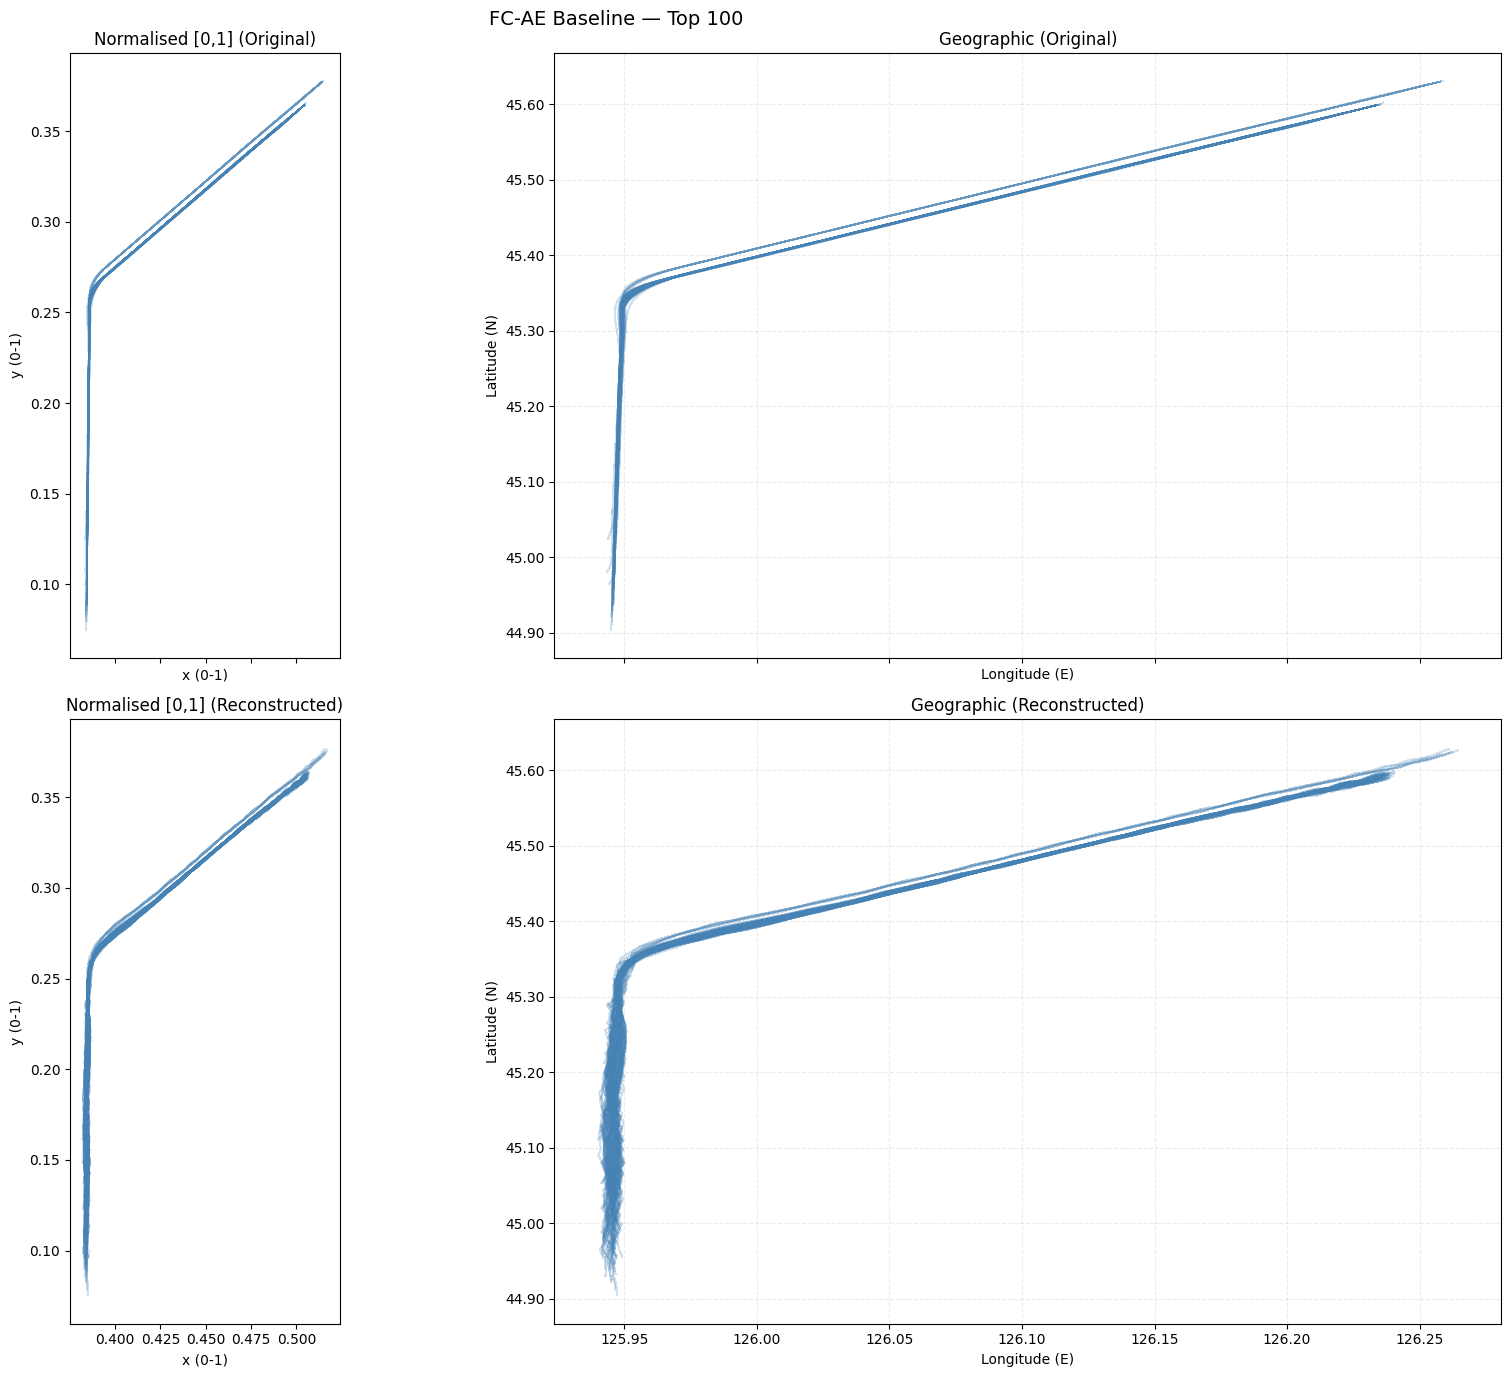

FC-AE done, GPU cache cleared.


In [36]:
# ---- FC-AE baseline -------------------------------------------------------
if os.path.exists(FC_MODEL_PATH):
    from ae_utils import TrajectoryAutoencoder as _FCAE
    _fc = _FCAE(input_dim=2 * T, latent_dim=32).to(_device)
    _fc.load_state_dict(torch.load(FC_MODEL_PATH, map_location=_device))
    _viz_baseline(_fc, "FC-AE", "steelblue", _raw_b, _X_sc_b, _sc_b, _geo_params, T, OUT_DIR)
    del _fc
    torch.cuda.empty_cache()
    gc.collect()
    print("FC-AE done, GPU cache cleared.")
else:
    print(f"Model not found: {FC_MODEL_PATH}")

e:\infovis\ae_utils.py:366: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(model_path, map_location=device)


LSTM-AE best-100 RMSE (01-space): [0.00847, 0.01032]


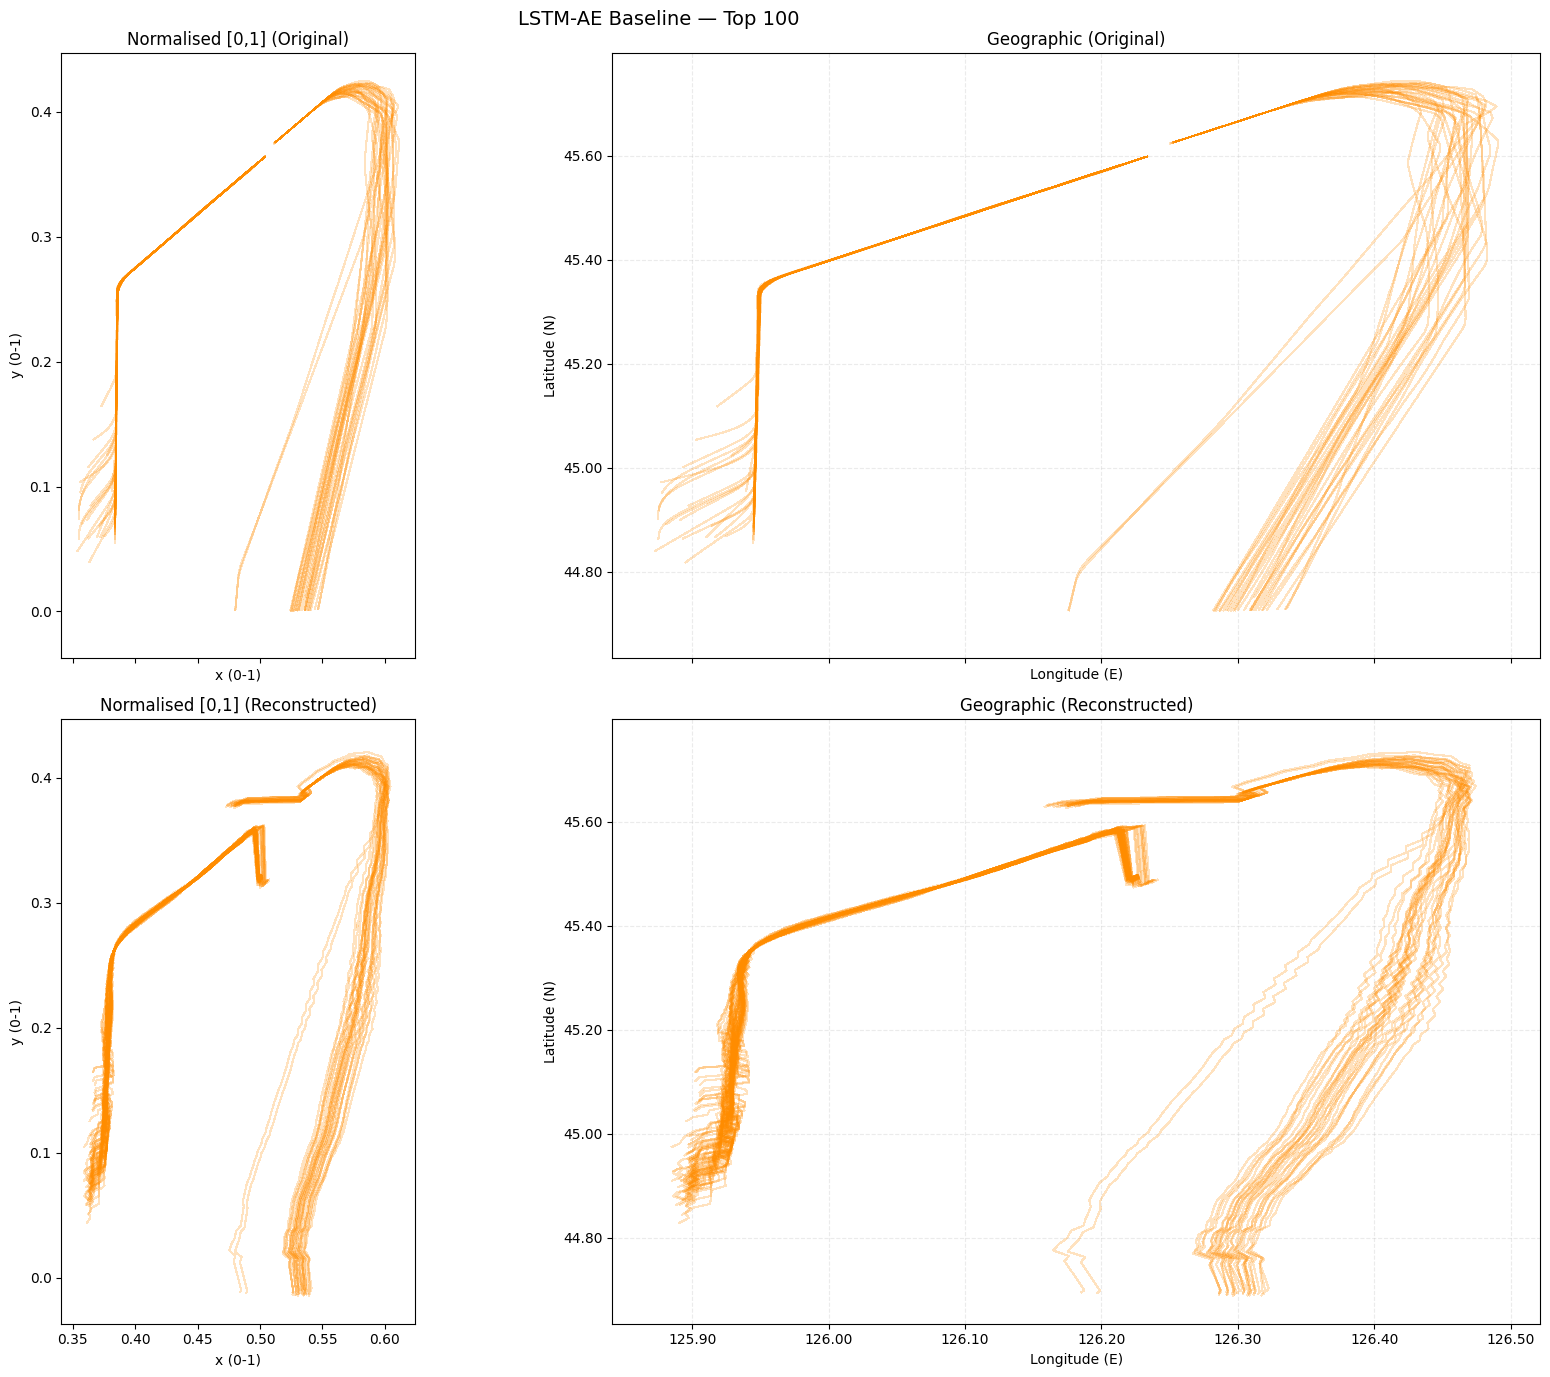

LSTM-AE done, GPU cache cleared.


In [37]:
# ---- LSTM-AE baseline -----------------------------------------------------
if os.path.exists(LSTM_MODEL_PATH):
    from ae_utils import TrajectoryLSTMAE as _LSTMAE, _load_lstm_ae as _load_lstm
    _lstm, _ = _load_lstm(LSTM_MODEL_PATH, _device)
    _viz_baseline(_lstm, "LSTM-AE", "darkorange", _raw_b, _X_sc_b, _sc_b, _geo_params, T, OUT_DIR)
    del _lstm
    torch.cuda.empty_cache()
    gc.collect()
    print("LSTM-AE done, GPU cache cleared.")
else:
    print(f"Model not found: {LSTM_MODEL_PATH}")


GRU-AE best-100 RMSE (01-space): [0.00769, 0.00857]


e:\infovis\ae_utils.py:377: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(model_path, map_location=device)


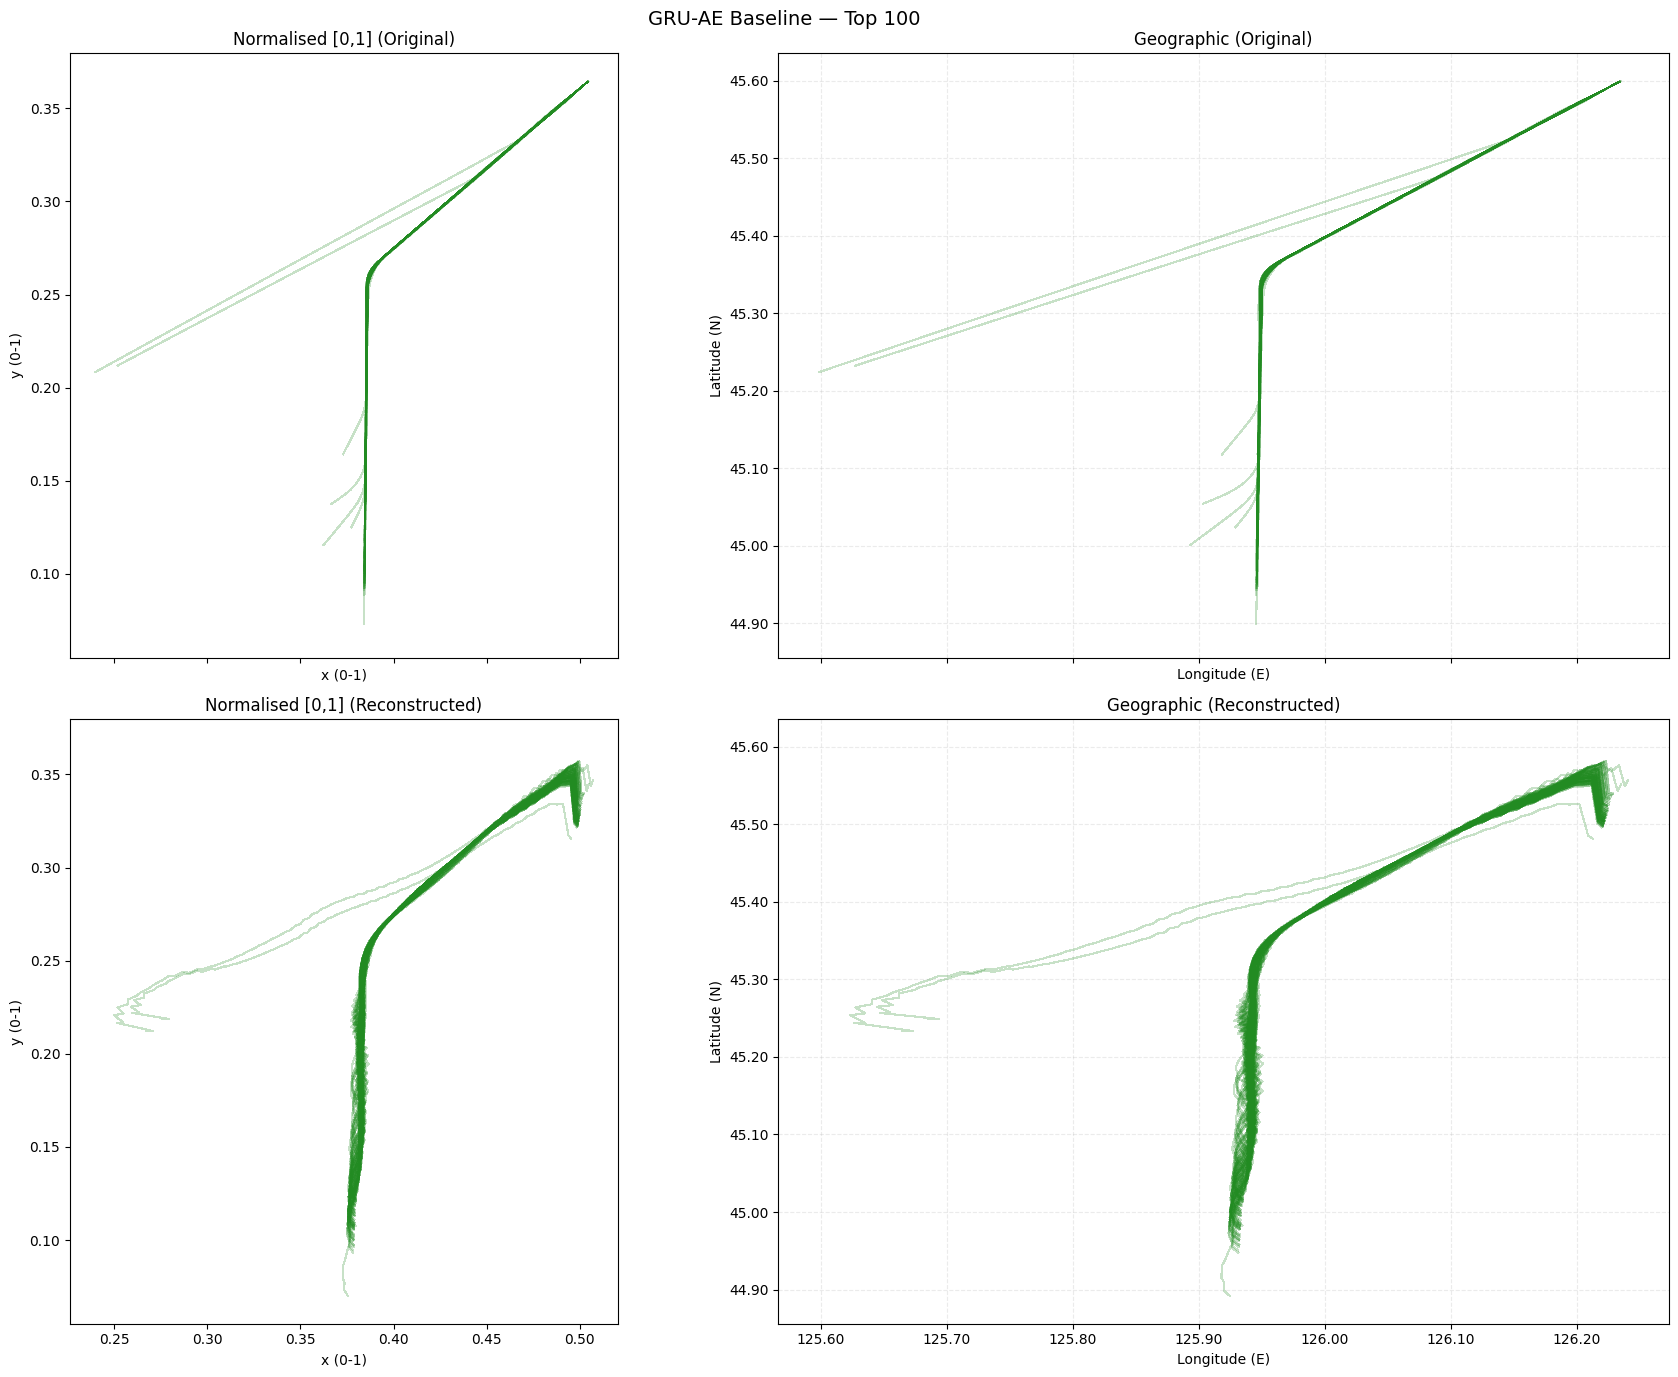

GRU-AE done, GPU cache cleared.
Shared data released.


In [38]:
# ---- GRU-AE baseline ------------------------------------------------------
if os.path.exists(GRU_MODEL_PATH):
    from ae_utils import _load_gru_ae as _load_gru
    _gru, _ = _load_gru(GRU_MODEL_PATH, _device)
    _viz_baseline(_gru, "GRU-AE", "forestgreen", _raw_b, _X_sc_b, _sc_b, _geo_params, T, OUT_DIR)
    del _gru
    torch.cuda.empty_cache()
    gc.collect()
    print("GRU-AE done, GPU cache cleared.")
else:
    print(f"Model not found: {GRU_MODEL_PATH}")

# ---- cleanup shared data --------------------------------------------------
del _raw_b, _X_sc_b, _b_lines, _sc_b, _geo_params
gc.collect()
print("Shared data released.")


Loaded 2,482 trajectories for UMAP


C:\Users\93176\AppData\Local\Temp\ipykernel_35184\2927692551.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  _m.load_state_dict(torch.load(FC_MODEL_PATH, map_location=_

  FC-AE latent: (2482, 32)


e:\infovis\ae_utils.py:366: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(model_path, map_location=device)


  LSTM-AE latent: (2482, 32)


...

e:\Users\93176\anaconda3\envs\ae_env\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP for GRU-AE ((2482, 32)) ...


e:\Users\93176\anaconda3\envs\ae_env\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP for LSTM-AE ((2482, 32)) ...


e:\Users\93176\anaconda3\envs\ae_env\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


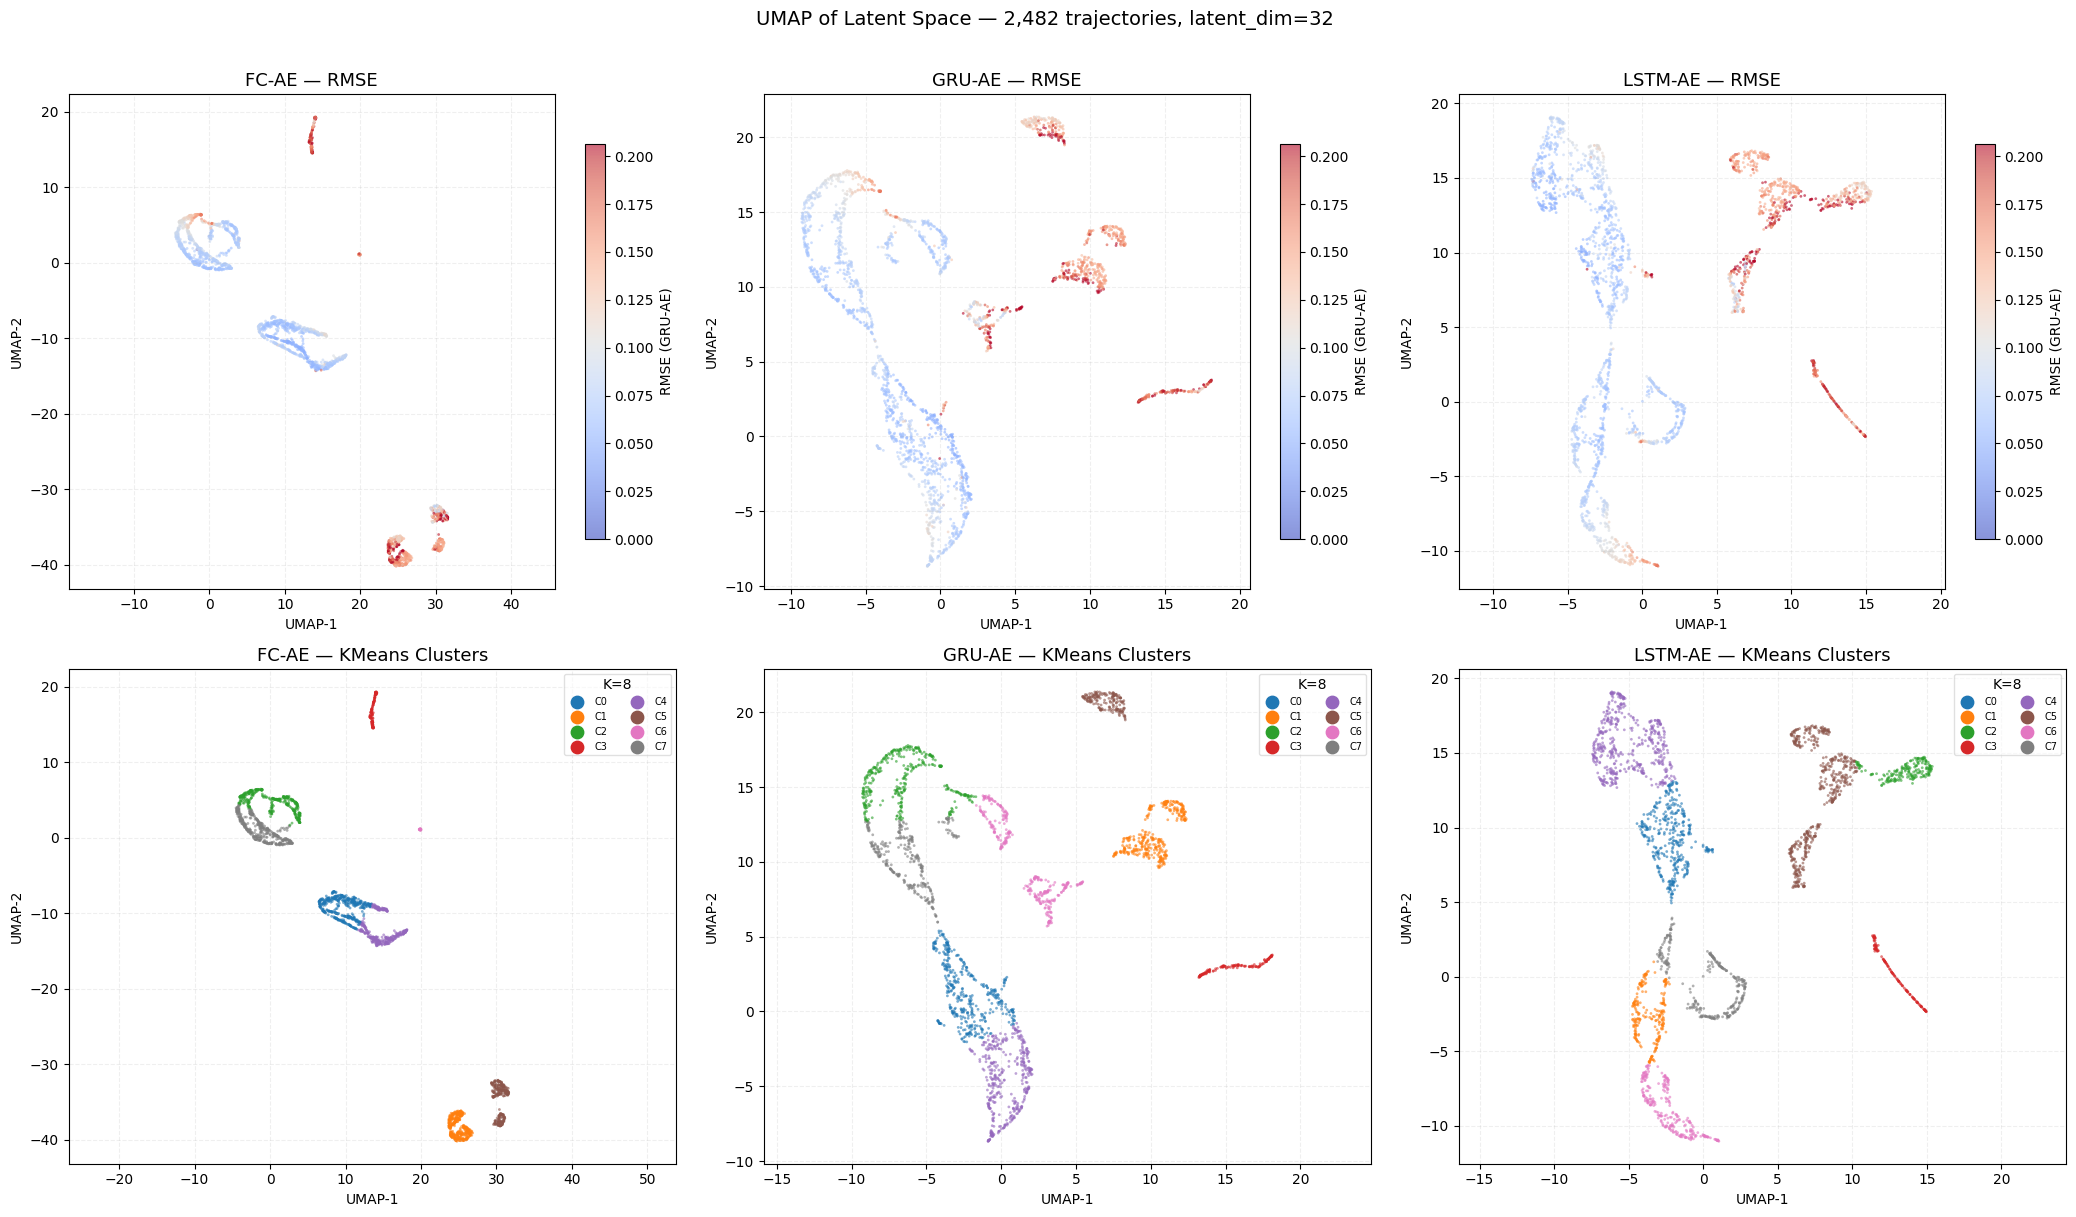

  Saved -> haerbin_output\umap_latent_space.png
UMAP 可视化完成。


In [39]:
# ── UMAP Latent Space Visualisation ───────────────────────────────
import torch, gc
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from umap import UMAP
import sys; sys.path.insert(0, "e:/infovis")
from ae_utils import TrajectoryAutoencoder, TrajectoryGRUAE, _load_lstm_ae, _load_gru_ae

LATENT_DIM = 32
_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── 加载数据 ──────────────────────────────────────────────────────
_df_u   = pd.read_csv(RESAMPLED_CSV)
_sc_u   = joblib.load(SCALER_PATH)
_segs_u = {fid: grp[["x", "y"]].values for fid, grp in _df_u.groupby("flight_id")}
_fids_u = [fid for fid, arr in _segs_u.items() if len(arr) == T]
_lines_u = [_segs_u[fid] for fid in _fids_u]
_raw_u  = np.array([np.concatenate([s[:, 0], s[:, 1]]) for s in _lines_u], dtype=np.float32)
_X_sc_u = _sc_u.transform(_raw_u).astype(np.float32)
_X_t    = torch.from_numpy(_X_sc_u).to(_device)
print(f"Loaded {len(_fids_u):,} trajectories for UMAP")

# ── 提取每个模型的 latent vectors ─────────────────────────────────
_latents = {}

# FC-AE
if os.path.exists(FC_MODEL_PATH):
    _m = TrajectoryAutoencoder(input_dim=2*T, latent_dim=LATENT_DIM).to(_device)
    _m.load_state_dict(torch.load(FC_MODEL_PATH, map_location=_device))
    _m.eval()
    with torch.no_grad():
        _latents["FC-AE"] = _m.encode(_X_t).cpu().numpy()
    del _m; torch.cuda.empty_cache(); gc.collect()
    print(f"  FC-AE latent: {_latents['FC-AE'].shape}")

# LSTM-AE
if os.path.exists(LSTM_MODEL_PATH):
    _m, _ = _load_lstm_ae(LSTM_MODEL_PATH, _device)
    _m.eval()
    with torch.no_grad():
        _latents["LSTM-AE"] = _m.encode(_X_t).cpu().numpy()
    del _m; torch.cuda.empty_cache(); gc.collect()
    print(f"  LSTM-AE latent: {_latents['LSTM-AE'].shape}")

# GRU-AE
if os.path.exists(GRU_MODEL_PATH):
    _m, _ = _load_gru_ae(GRU_MODEL_PATH, _device)
    _m.eval()
    with torch.no_grad():
        _latents["GRU-AE"] = _m.encode(_X_t).cpu().numpy()
    del _m; torch.cuda.empty_cache(); gc.collect()
    print(f"  GRU-AE latent: {_latents['GRU-AE'].shape}")

del _X_t

# ── 计算每条轨迹的重建误差（用于着色） ────────────────────────────
_color_model_name = None
for _pref in ["GRU-AE", "LSTM-AE", "FC-AE"]:
    if _pref in _latents:
        _color_model_name = _pref
        break

_recon_all = None
if _color_model_name:
    if _color_model_name == "FC-AE":
        _cm = TrajectoryAutoencoder(input_dim=2*T, latent_dim=LATENT_DIM).to(_device)
        _cm.load_state_dict(torch.load(FC_MODEL_PATH, map_location=_device))
    elif _color_model_name == "LSTM-AE":
        _cm, _ = _load_lstm_ae(LSTM_MODEL_PATH, _device)
    else:
        _cm, _ = _load_gru_ae(GRU_MODEL_PATH, _device)
    _cm.eval()
    with torch.no_grad():
        _recon_all = _cm(torch.from_numpy(_X_sc_u).to(_device)).cpu().numpy()
    _rmse = np.sqrt(((_recon_all - _X_sc_u) ** 2).mean(axis=1))
    del _cm; torch.cuda.empty_cache(); gc.collect()
    print(f"  RMSE ({_color_model_name}): min={_rmse.min():.4f}, "
          f"median={np.median(_rmse):.4f}, max={_rmse.max():.4f}")
else:
    _rmse = None

# ── UMAP 降维 + 双行绘图 ────────────────────────────────────────
# 第一行：RMSE 着色  |  第二行：KMeans 簇着色
from sklearn.cluster import KMeans
N_CLUSTERS = 8  # 可调整

n_models = len(_latents)
if n_models == 0:
    print("没有找到任何已训练的模型，跳过 UMAP。")
else:
    _umap_params = dict(n_components=2, n_neighbors=30, min_dist=0.3,
                        metric="euclidean", random_state=42)
    _cmap_cls = plt.get_cmap("tab10")

    fig, axes = plt.subplots(2, n_models, figsize=(7 * n_models, 12), squeeze=False)

    for col, (name, Z) in enumerate(sorted(_latents.items())):
        print(f"  UMAP for {name} ({Z.shape}) ...")
        emb = UMAP(**_umap_params).fit_transform(Z)

        # ── 第一行：RMSE 着色 ──────────────────────────────────────
        ax0 = axes[0, col]
        if _rmse is not None:
            _vmax = np.percentile(_rmse, 95)
            sc = ax0.scatter(emb[:, 0], emb[:, 1], c=_rmse, cmap="coolwarm",
                             s=4, alpha=0.6, vmin=0, vmax=_vmax, edgecolors="none")
            plt.colorbar(sc, ax=ax0, shrink=0.8, label=f"RMSE ({_color_model_name})")
        else:
            ax0.scatter(emb[:, 0], emb[:, 1], s=4, alpha=0.5,
                        color="steelblue", edgecolors="none")
        ax0.set_title(f"{name} — RMSE", fontsize=13)
        ax0.set_xlabel("UMAP-1"); ax0.set_ylabel("UMAP-2")
        ax0.set_aspect("equal", adjustable="datalim")
        ax0.grid(True, alpha=0.2, linestyle="--")

        # ── 第二行：KMeans 簇着色 ──────────────────────────────────
        ax1 = axes[1, col]
        labels = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init="auto").fit_predict(emb)
        ax1.scatter(emb[:, 0], emb[:, 1],
                    c=[_cmap_cls(lb % 10) for lb in labels],
                    s=4, alpha=0.6, edgecolors="none")
        for k in range(N_CLUSTERS):
            ax1.scatter([], [], color=_cmap_cls(k), s=20, label=f"C{k}")
        ax1.legend(loc="upper right", fontsize=7, ncol=2,
                   framealpha=0.6, markerscale=2, title=f"K={N_CLUSTERS}")
        ax1.set_title(f"{name} — KMeans Clusters", fontsize=13)
        ax1.set_xlabel("UMAP-1"); ax1.set_ylabel("UMAP-2")
        ax1.set_aspect("equal", adjustable="datalim")
        ax1.grid(True, alpha=0.2, linestyle="--")

    fig.suptitle(f"UMAP of Latent Space — {len(_fids_u):,} trajectories, latent_dim={LATENT_DIM}",
                 fontsize=14, y=1.01)
    fig.tight_layout()
    _umap_path = os.path.join(OUT_DIR, "umap_latent_space.png")
    plt.savefig(_umap_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved -> {_umap_path}")

# 保留 _fids_u, _rmse, _raw_u, _sc_u, _recon_all, _X_sc_u 供下一个 cell 使用
del _latents, _df_u, _lines_u, _segs_u
gc.collect()
print("UMAP 可视化完成。")


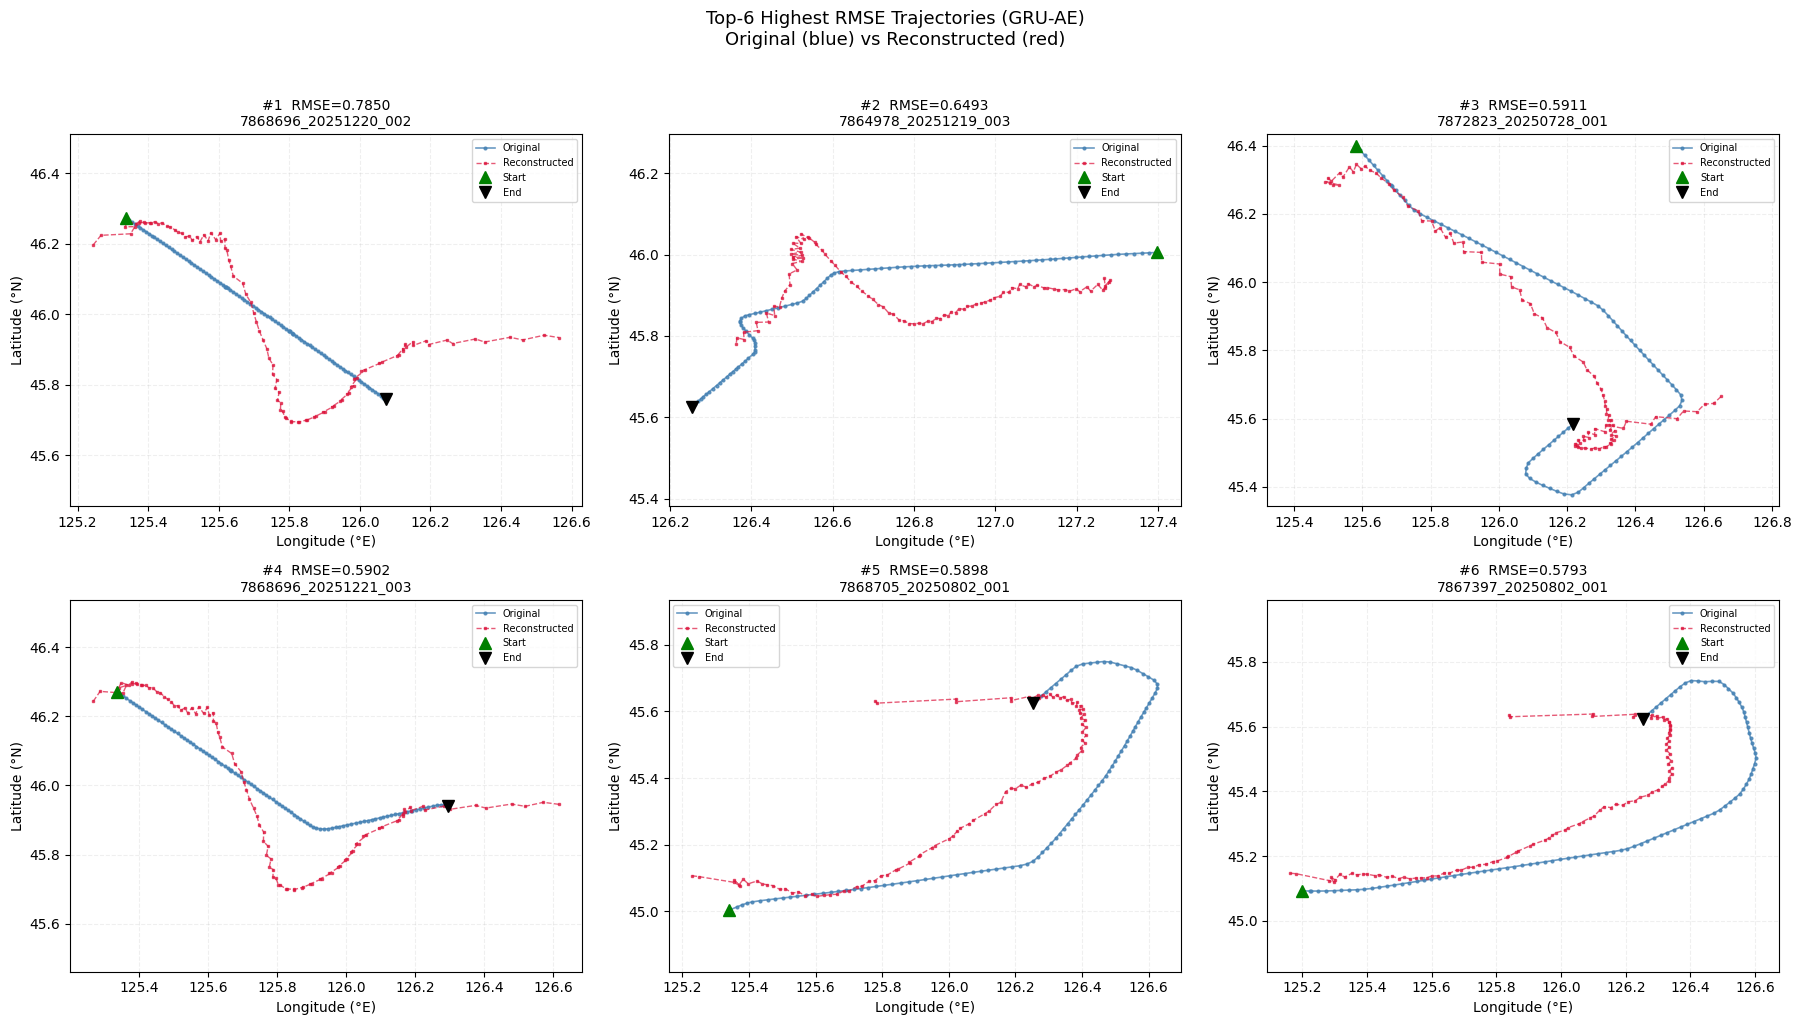

Saved -> haerbin_output\umap_high_rmse_trajectories.png
高 RMSE 轨迹可视化完成，内存已释放。


In [40]:
# ── 高 RMSE 轨迹可视化：原始 vs 重建（地理坐标） ─────────────────
import matplotlib.pyplot as plt
import joblib, gc

N_SHOW = 6   # 展示几条高 RMSE 轨迹

_geo_p = joblib.load(GEO_PARAMS_PATH)
_xmin, _ymin, _mr = _geo_p["x_min"], _geo_p["y_min"], _geo_p["max_range"]

# 按 RMSE 从高到低排序，取前 N_SHOW 条
_top_idx = np.argsort(_rmse)[::-1][:N_SHOW]

# 反归一化函数：scaler space → [0,1] space → geographic
def _to_geo_single(vec_sc, sc, xmin, ymin, mr, T):
    """vec_sc: (2T,) in scaler space -> (T,2) in geographic lng/lat."""
    vec_01 = sc.inverse_transform(vec_sc.reshape(1, -1)).ravel()
    lng = vec_01[:T] * mr + xmin
    lat = vec_01[T:] * mr + ymin
    return lng, lat

ncols = 3
nrows = (N_SHOW + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = axes.ravel() if N_SHOW > 1 else [axes]

for k, idx in enumerate(_top_idx):
    ax = axes[k]
    fid = _fids_u[idx]
    rmse_val = _rmse[idx]

    # 原始轨迹（地理坐标）
    orig_lng, orig_lat = _to_geo_single(_X_sc_u[idx], _sc_u, _xmin, _ymin, _mr, T)
    # 重建轨迹（地理坐标）
    recon_lng, recon_lat = _to_geo_single(_recon_all[idx], _sc_u, _xmin, _ymin, _mr, T)

    ax.plot(orig_lng, orig_lat, "o-", color="steelblue", ms=2, lw=1.2,
            alpha=0.8, label="Original")
    ax.plot(recon_lng, recon_lat, "s--", color="crimson", ms=2, lw=1.0,
            alpha=0.7, label="Reconstructed")

    # 标记起点和终点
    ax.plot(orig_lng[0], orig_lat[0], "^", color="green", ms=8, zorder=5, label="Start")
    ax.plot(orig_lng[-1], orig_lat[-1], "v", color="black", ms=8, zorder=5, label="End")

    ax.set_title(f"#{k+1}  RMSE={rmse_val:.4f}\n{fid}", fontsize=10)
    ax.set_xlabel("Longitude (°E)")
    ax.set_ylabel("Latitude (°N)")
    ax.legend(fontsize=7, loc="best")
    ax.grid(True, alpha=0.2, linestyle="--")
    ax.set_aspect("equal", adjustable="datalim")

# 隐藏多余子图
for k in range(N_SHOW, len(axes)):
    axes[k].set_visible(False)

fig.suptitle(f"Top-{N_SHOW} Highest RMSE Trajectories ({_color_model_name})\n"
             f"Original (blue) vs Reconstructed (red)",
             fontsize=13, y=1.02)
fig.tight_layout()
_hi_path = os.path.join(OUT_DIR, "umap_high_rmse_trajectories.png")
plt.savefig(_hi_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved -> {_hi_path}")

# ── 清理 ─────────────────────────────────────────────────────────
del _raw_u, _X_sc_u, _recon_all, _rmse, _fids_u, _sc_u, _geo_p
gc.collect()
print("高 RMSE 轨迹可视化完成，内存已释放。")

共 2,482 条轨迹用于 baseline 评分


C:\Users\93176\AppData\Local\Temp\ipykernel_35184\2037936923.py:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  _m_ni.load_state_dict(torch.load(_path_ni, map_location=_de

FC-AE best-100 MSE: [7.06e-07, 1.94e-06]


e:\infovis\ae_utils.py:366: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(model_path, map_location=device)


LSTM-AE best-100 MSE: [3.59e-05, 5.32e-05]


e:\infovis\ae_utils.py:377: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(model_path, map_location=device)


GRU-AE best-100 MSE: [2.96e-05, 3.67e-05]


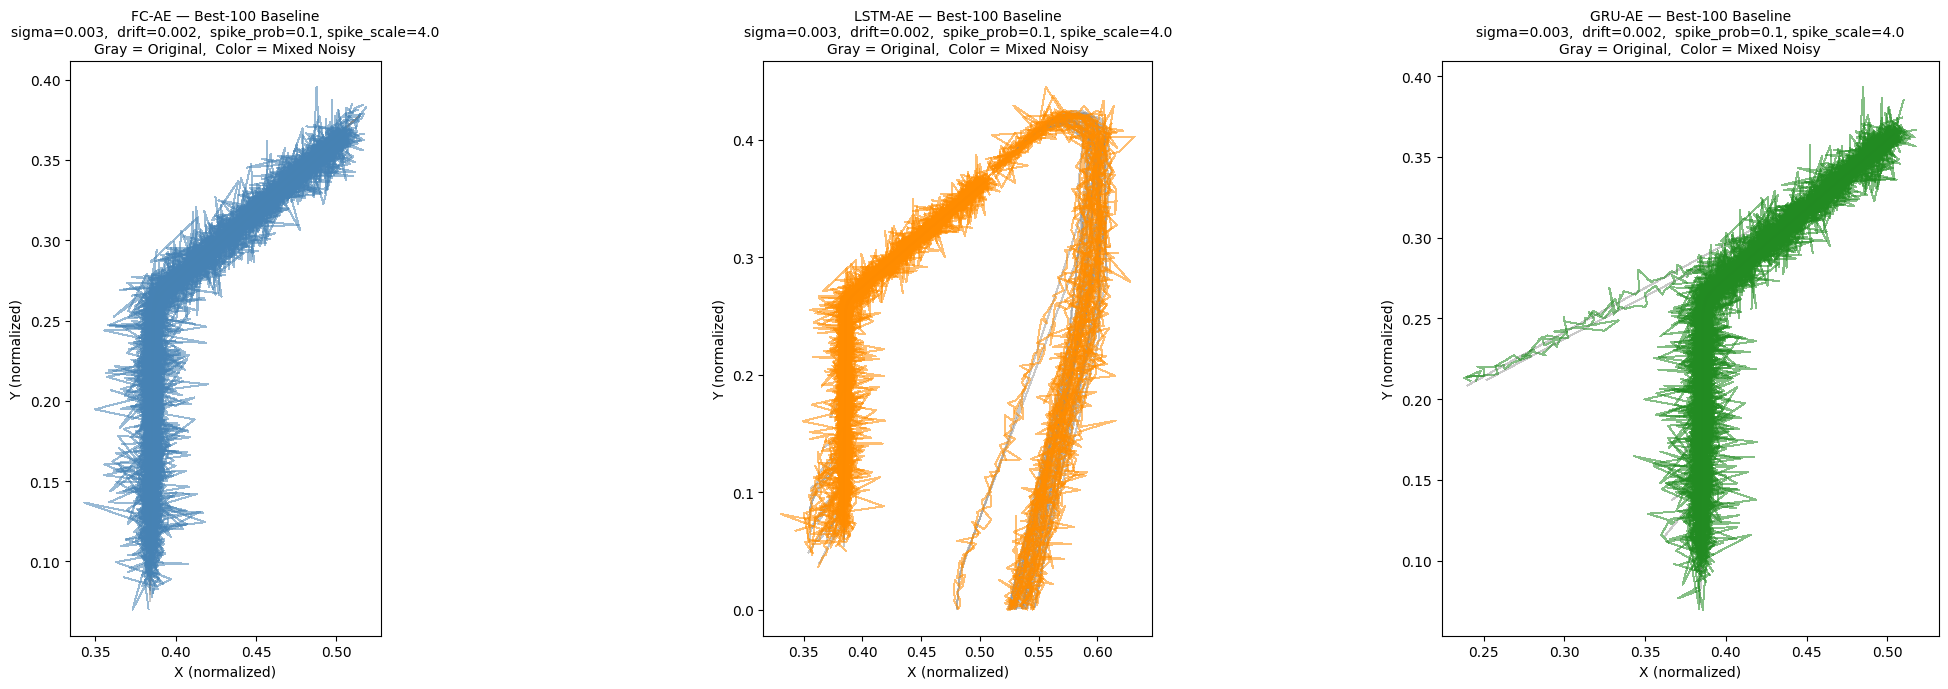

Saved -> haerbin_output\viz_noise_illustration.png


11257

In [41]:
# -- Noise Illustration: Mixed noise on each model's own baseline --
# Gray = original trajectories; colored = after mixed noise
import torch, gc
import sys; sys.path.insert(0, 'e:/infovis')
from ae_utils import (TrajectoryAutoencoder as _FCAE_ni,
                      _load_lstm_ae as _load_lstm_ni, _load_gru_ae as _load_gru_ni,
                      _add_noise_mixed)
import joblib as _jbl_ni
from matplotlib.collections import LineCollection

# ---- noise parameters (choose one representative set) ----------------
_NI_STD   = 0.003
_NI_DRIFT = 0.002
_NI_SPIKE = 0.10
_NI_SCALE = 4.0
_NI_SEED  = 42
_NI_N     = 100   # best-N per model

_device_ni = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
_sc_ni     = _jbl_ni.load(SCALER_PATH)
_geo_ni    = _jbl_ni.load(GEO_PARAMS_PATH)

# ---- load all trajectories and score each model ----------------------
_df_ni    = pd.read_csv(RESAMPLED_CSV)
_cnt_ni   = _df_ni.groupby('flight_id')['x'].count()
_ids_ni   = _cnt_ni.index[_cnt_ni == T].astype(str).to_numpy()
_df_ni2   = _df_ni[_df_ni['flight_id'].astype(str).isin(_ids_ni)].copy()
_df_ni2['_r'] = _df_ni2.groupby('flight_id').cumcount()
_xw = _df_ni2.pivot(index='flight_id', columns='_r', values='x').dropna()
_yw = _df_ni2.pivot(index='flight_id', columns='_r', values='y').reindex(_xw.index).dropna()
_xw = _xw.reindex(_yw.index)
_X_all_ni = np.concatenate([_xw.to_numpy(np.float32), _yw.to_numpy(np.float32)], axis=1)
_Xs_ni    = _sc_ni.transform(_X_all_ni).astype(np.float32)
_Xt_ni    = torch.from_numpy(_Xs_ni).to(_device_ni)
print(f'共 {len(_X_all_ni):,} 条轨迹用于 baseline 评分')

@torch.no_grad()
def _mse_ni(model):
    parts = []
    for i in range(0, len(_Xt_ni), 512):
        recon_sc = model(_Xt_ni[i:i+512]).float().cpu().numpy()
        parts.append(_sc_ni.inverse_transform(recon_sc))
    recon = np.concatenate(parts, 0)
    return (((_X_all_ni - recon) ** 2).mean(axis=1))

_models_ni = [
    ('FC-AE',   FC_MODEL_PATH,   'steelblue'),
    ('LSTM-AE', LSTM_MODEL_PATH, 'darkorange'),
    ('GRU-AE',  GRU_MODEL_PATH,  'forestgreen'),
]

# ---- score and pick best-N for each model ----------------------------
_baselines_ni = []   # list of (label, color, X_best[0,1], X_noisy[0,1])
for _lbl_ni, _path_ni, _clr_ni in _models_ni:
    if not os.path.exists(_path_ni):
        print(f'Skipping {_lbl_ni}: not found'); continue
    if _lbl_ni == 'FC-AE':
        _m_ni = _FCAE_ni(2 * T, 32).to(_device_ni)
        _m_ni.load_state_dict(torch.load(_path_ni, map_location=_device_ni))
    elif _lbl_ni == 'LSTM-AE':
        _m_ni, _ = _load_lstm_ni(_path_ni, _device_ni)
    else:
        _m_ni, _ = _load_gru_ni(_path_ni, _device_ni)
    _mse_v = _mse_ni(_m_ni)
    del _m_ni; torch.cuda.empty_cache(); gc.collect()
    _best_idx_ni = np.argsort(_mse_v)[:_NI_N]
    _X_best_ni   = _X_all_ni[_best_idx_ni]          # (N, 2T) in [0,1]
    _X_noisy_ni  = _add_noise_mixed(
        _X_best_ni, T, _NI_STD, _NI_DRIFT, _NI_SPIKE, _NI_SCALE, seed=_NI_SEED)
    _baselines_ni.append((_lbl_ni, _clr_ni, _X_best_ni, _X_noisy_ni))
    print(f'{_lbl_ni} best-{_NI_N} MSE: [{_mse_v[_best_idx_ni].min():.2e}, {_mse_v[_best_idx_ni].max():.2e}]')

# ---- plot 1x3 panels -------------------------------------------------
_n_panels = len(_baselines_ni)
fig_ni, axes_ni = plt.subplots(1, _n_panels, figsize=(7.5 * _n_panels, 7))
if _n_panels == 1: axes_ni = [axes_ni]

for ax_ni, (_lbl_ni, _clr_ni, _Xb, _Xn) in zip(axes_ni, _baselines_ni):
    _segs_orig  = [np.column_stack([_Xb[i, :T], _Xb[i, T:]]) for i in range(len(_Xb))]
    _segs_noisy = [np.column_stack([_Xn[i, :T], _Xn[i, T:]]) for i in range(len(_Xn))]

    _lc_o = LineCollection(_segs_orig,  linewidths=0.7, alpha=0.45,
                           antialiased=False, colors='#888888')
    _lc_o.set_rasterized(True)
    _lc_n = LineCollection(_segs_noisy, linewidths=0.7, alpha=0.55,
                           antialiased=False, colors=_clr_ni)
    _lc_n.set_rasterized(True)

    ax_ni.add_collection(_lc_o)
    ax_ni.add_collection(_lc_n)
    ax_ni.autoscale()
    ax_ni.set_aspect('equal', adjustable='box')
    ax_ni.grid(False)
    ax_ni.set_xlabel('X (normalized)')
    ax_ni.set_ylabel('Y (normalized)')
    ax_ni.set_title(
        f'{_lbl_ni} — Best-{_NI_N} Baseline\n'
        f'sigma={_NI_STD},  drift={_NI_DRIFT},  '
        f'spike_prob={_NI_SPIKE}, spike_scale={_NI_SCALE}\n'
        'Gray = Original,  Color = Mixed Noisy',
        fontsize=10)

fig_ni.tight_layout()
_noise_path = os.path.join(OUT_DIR, 'viz_noise_illustration.png')
plt.savefig(_noise_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {_noise_path}')

del _df_ni, _df_ni2, _xw, _yw, _X_all_ni, _Xs_ni, _Xt_ni, _baselines_ni
gc.collect()


e:\infovis\ae_utils.py:354: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd     = torch.load(model_path, map_location=device)
e:\infovis\ae_utils.py:366: FutureWarning: You

[Exp-B] Total valid flights: 2482  T=100
  Scoring all flights (FC-AE) ...
  Scoring all flights (LSTM-AE) ...
  FC-AE   best-100: MSE [1.60e-05, 9.47e-04]
  LSTM-AE best-100: MSE [1.62e-04, 4.37e-03]
  Scoring all flights (GRU-AE) ...
  GRU-AE  best-100: MSE [8.95e-05, 2.36e-03]
[Exp-B] Running sweeps ...
  Model: FC-AE
     25.0%  [Gaussian] done
     50.0%  [Drift] done
     75.0%  [Spike] done
    100.0%  [Missing data] done
  Model: LSTM-AE
     25.0%  [Gaussian] done
     50.0%  [Drift] done
     75.0%  [Spike] done
    100.0%  [Missing data] done
  Model: GRU-AE
     25.0%  [Gaussian] done
     50.0%  [Drift] done
     75.0%  [Spike] done
    100.0%  [Missing data] done
  Saved -> haerbin_output\exp_B_separate_best100.png


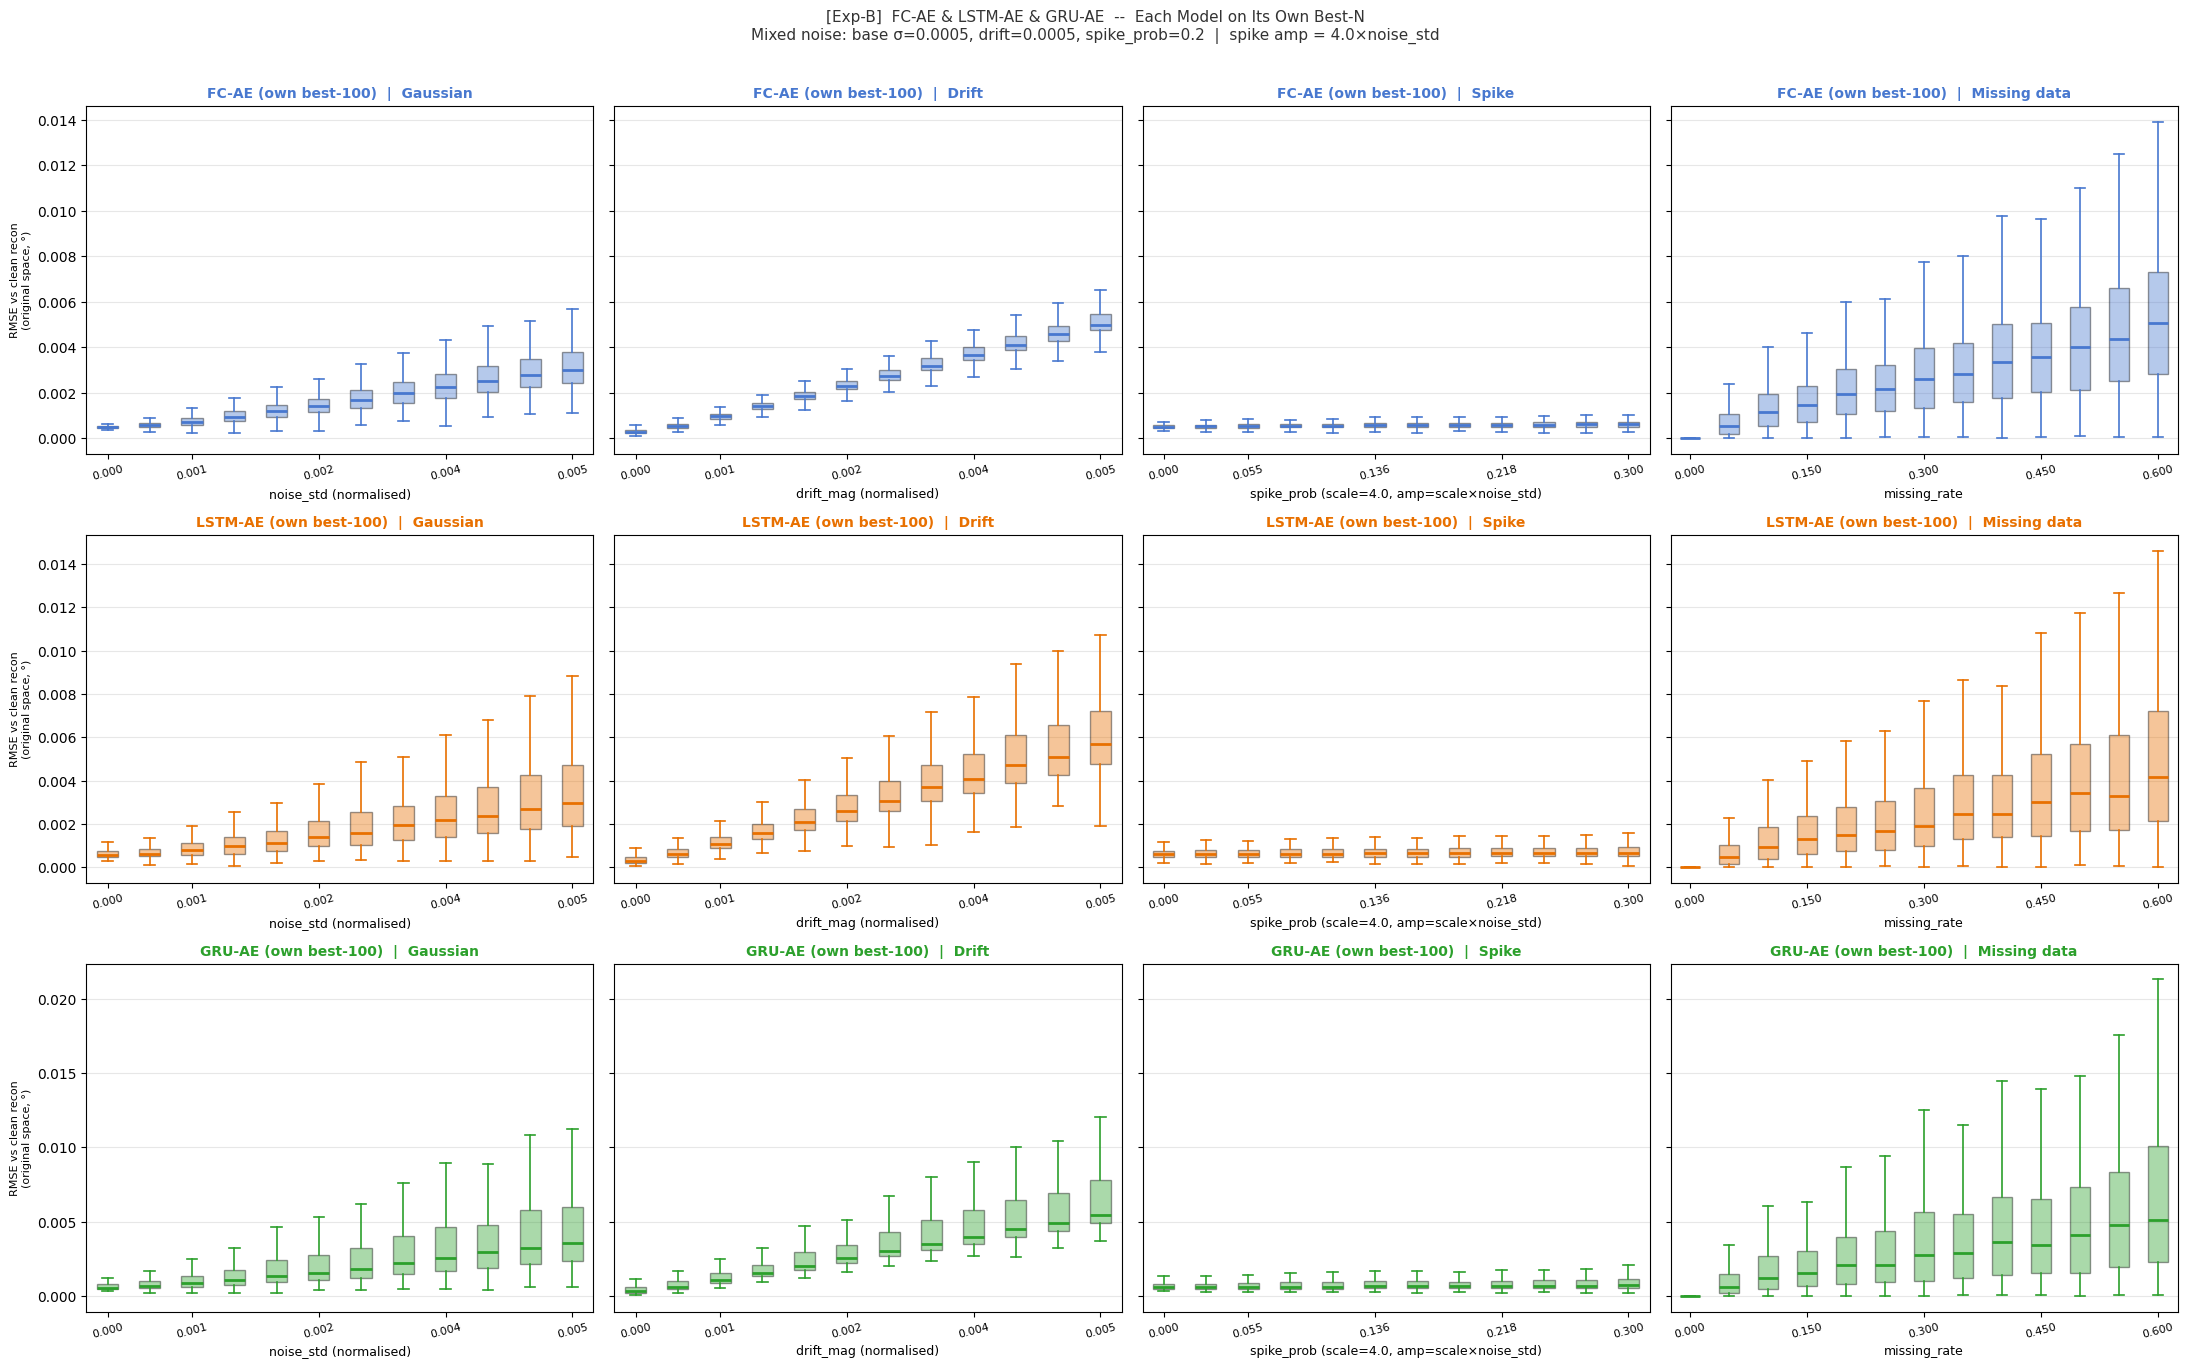

In [11]:
import numpy as np
from ae_utils import compare_noise_sweep_separate_best

# Experiment B: each model on its own best-100
# 4 noise types: Gaussian / Drift / Spike / Missing
# Gaussian/Drift/Spike 使用混合背景噪声（zakData-style），spike amp = spike_scale × noise_std
# Missing 独立施加（线性插值）
results_B = compare_noise_sweep_separate_best(
    resampled_csv   = RESAMPLED_CSV,
    scaler_path     = SCALER_PATH,
    fc_model_path   = FC_MODEL_PATH,
    lstm_model_path = LSTM_MODEL_PATH,
    gru_model_path  = GRU_MODEL_PATH,
    N       = 100,
    n_runs  = 5,
    # noise_stds    = np.linspace(0, 0.005, 12),   # 与 zakData 一致：0 ~ 0.005，12 级
    # drift_mags    = np.linspace(0, 0.005, 12),   # 与 zakData 一致：0 ~ 0.005，12 级
    # spike_probs   = np.linspace(0, 0.30,  12),   # 与 zakData 一致：0 ~ 0.30，12 级
    # missing_rates = np.linspace(0, 0.60,  13),   # Missing 保留原范围：0 ~ 0.60，13 级
    # base_noise_std  = 0.0005,                     # 与 zakData base_noise_std 一致
    # base_drift_mag  = 0.0005,                     # 与 zakData base_drift_mag 一致
    # base_spike_prob = 0.2,                        # 与 zakData base_spike_prob 一致
    # save_plot = True,
    plot_path = os.path.join(OUT_DIR, "exp_B_separate_best100.png"),
)

已保存 -> haerbin_output\exp_row.png


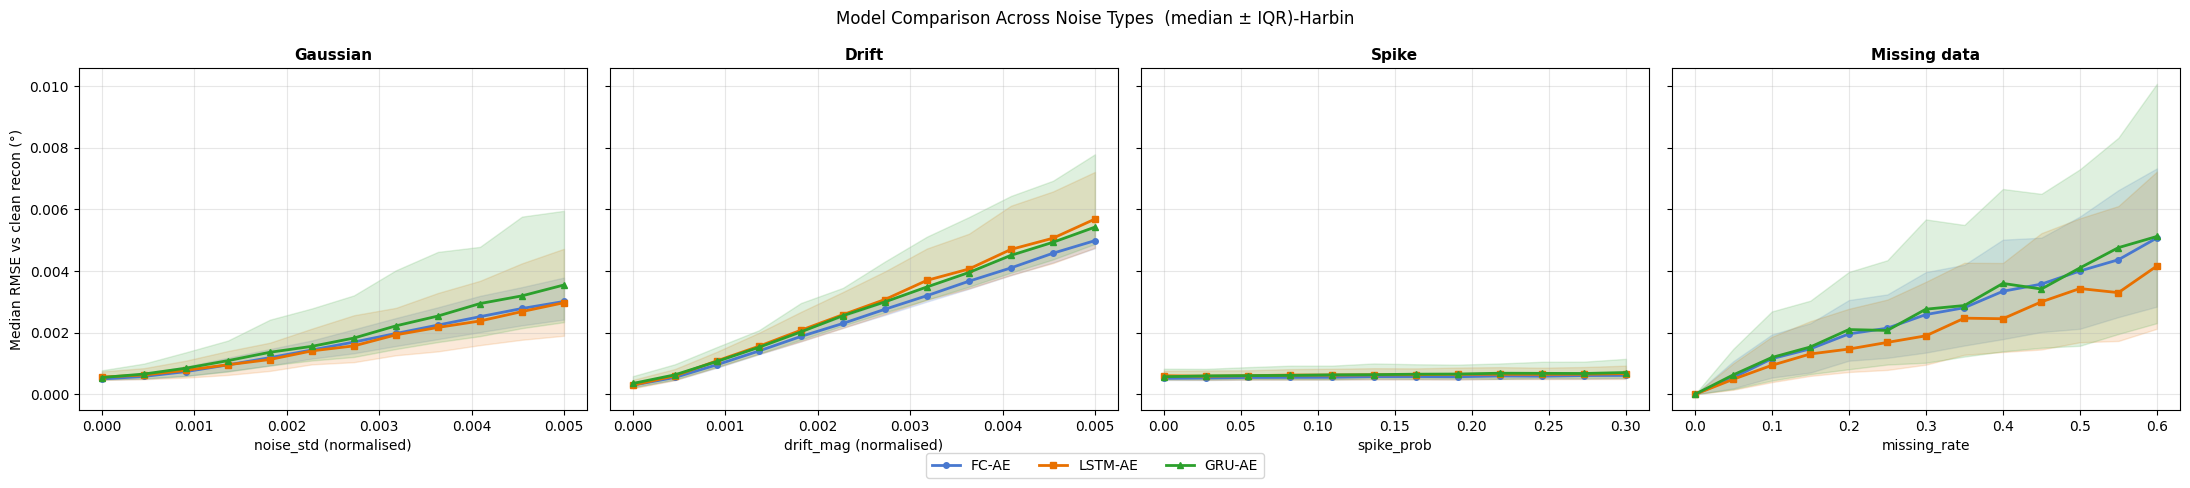

In [18]:
# -- Compact 1x4 comparison: each panel = one noise type, models overlaid by color
# Reuses results_B (no re-run). Shared y-axis across panels.
import matplotlib.pyplot as plt
import numpy as np

_model_names = [m for m in ["FC-AE", "LSTM-AE", "GRU-AE"] if m in results_B]
_NOISE_ORDER = list(list(results_B.values())[0].keys())
_COLORS  = {"FC-AE": "#4878CF", "LSTM-AE": "#E87000", "GRU-AE": "#2CA02C"}
_MARKERS = {"FC-AE": "o",       "LSTM-AE": "s",       "GRU-AE": "^"}

def _cmp_lookup(nname):
    n = nname.replace(chr(10), " ").lower()
    if "gaussian" in n:
        return np.linspace(0, 0.005, 12), "noise_std (normalised)"
    elif "drift" in n:
        return np.linspace(0, 0.005, 12), "drift_mag (normalised)"
    elif "spike" in n:
        return np.linspace(0, 0.30,  12), "spike_prob"
    elif "missing" in n:
        return np.linspace(0, 0.60,  13), "missing_rate"
    else:
        raise ValueError(f"Unknown noise type: {nname!r}")

fig_row, axes_row = plt.subplots(1, 4, figsize=(22, 5), sharey=True, squeeze=True)

for col, nname in enumerate(_NOISE_ORDER):
    ax = axes_row[col]
    params, xlabel = _cmp_lookup(nname)
    for mname in _model_names:
        color = _COLORS[mname]
        data  = results_B[mname][nname]          # list of lists, one per noise level
        meds  = np.array([np.median(v) for v in data])
        q25   = np.array([np.percentile(v, 25)  for v in data])
        q75   = np.array([np.percentile(v, 75)  for v in data])
        ax.plot(params, meds, color=color, linewidth=2,
                marker=_MARKERS[mname], markersize=4, label=mname)
        ax.fill_between(params, q25, q75, color=color, alpha=0.15)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_title(nname.split(chr(10))[0], fontsize=11, fontweight="bold")
    ax.grid(True, alpha=0.3)
    if col == 0:
        ax.set_ylabel("Median RMSE vs clean recon (°)", fontsize=10)

fig_row.suptitle(
    "Model Comparison Across Noise Types  (median ± IQR)-Harbin",
    fontsize=12,
)
fig_row.tight_layout()
fig_row.subplots_adjust(bottom=0.18)   # reserve space for shared legend
_handles, _labels = axes_row[0].get_legend_handles_labels()
fig_row.legend(_handles, _labels, loc="lower center", ncol=len(_model_names),
               fontsize=10, framealpha=0.8, bbox_to_anchor=(0.5, 0.03))
_row_path = os.path.join(OUT_DIR, "exp_row.png")
plt.savefig(_row_path, dpi=150, bbox_inches="tight")
print(f"已保存 -> {_row_path}")
plt.show()


In [43]:
# -- Statistical Significance: Wilcoxon signed-rank on ΔRMSE across noise types --
# Reviewer: "quantitative statistical support for greater tolerance to drift/spike noise"
#
# Approach (Plan A):
#   ΔRMSE(noise_type) = RMSE(max_level) - RMSE(level_0)   per trajectory per run
#
# level_0 applies zero noise → RMSE is the model's clean reconstruction error.
# ΔRMSE measures how much each noise type degrades reconstruction at its maximum strength.
# Pairwise Wilcoxon signed-rank test compares ΔRMSE between noise types (paired by
# trajectory × run index, i.e. same underlying trajectory seen by both noise types).
#
# H0: median(ΔRMSE_A − ΔRMSE_B) = 0  (two-sided)
# Rejection → one noise type causes significantly larger RMSE degradation than the other.
from scipy.stats import wilcoxon
from itertools import combinations
import pandas as pd
import numpy as np

ALPHA = 0.05

_NOISE_KEYS = [
    'Gaussian',
    'Drift',
    'Spike',
    'Missing data\n(linear interp.)',
]
_SHORT = {
    'Gaussian':                       'Gaussian',
    'Drift':                          'Drift',
    'Spike':                          'Spike',
    'Missing data\n(linear interp.)': 'Missing',
}

def _delta_rmse(res_model):
    """Return dict: noise_key -> np.array of ΔRMSE (length n_runs*N)."""
    delta = {}
    for key in _NOISE_KEYS:
        if key not in res_model:
            continue
        levels = res_model[key]
        base   = np.array(levels[0],  dtype=float)   # level 0: no noise
        maxlvl = np.array(levels[-1], dtype=float)   # level max: full noise
        n = min(len(base), len(maxlvl))
        delta[key] = maxlvl[:n] - base[:n]           # ΔRMSE, paired by position
    return delta

def _pairwise_wilcoxon(delta, alpha=ALPHA):
    """All pairwise Wilcoxon signed-rank tests on ΔRMSE arrays."""
    keys = list(delta.keys())
    rows = []
    for ka, kb in combinations(keys, 2):
        a, b = delta[ka], delta[kb]
        n = min(len(a), len(b))
        diff = a[:n] - b[:n]   # ΔRMSE_A − ΔRMSE_B
        if np.all(diff == 0):
            stat, pval = np.nan, np.nan
        else:
            stat, pval = wilcoxon(diff, alternative='two-sided')
        med_a, med_b = np.median(a), np.median(b)
        if not np.isnan(pval) and pval < alpha:
            more_tolerant = _SHORT[kb] if med_a > med_b else _SHORT[ka]
        else:
            more_tolerant = '—'
        rows.append({
            'Noise A':           _SHORT[ka],
            'Noise B':           _SHORT[kb],
            'Median ΔRMSE A':    round(med_a, 7),
            'Median ΔRMSE B':    round(med_b, 7),
            'W-stat':            round(stat, 1) if not np.isnan(stat) else 'n/a',
            'p-value':           f'{pval:.3e}' if not np.isnan(pval) else 'n/a',
            'Significant':       'Yes *' if (not np.isnan(pval) and pval < alpha) else 'No',
            'More tolerant':     more_tolerant,
        })
    return pd.DataFrame(rows)

print(f"Max noise levels used:")
for _k in _NOISE_KEYS:
    if _k in results_B[list(results_B.keys())[0]]:
        _n = len(results_B[list(results_B.keys())[0]][_k])
        print(f"  {_SHORT[_k]}: {_n} levels, max index = {_n-1}")

for _model_sig in results_B.keys():
    print(f"\n{'='*65}")
    print(f"Model: {_model_sig}")
    _delta = _delta_rmse(results_B[_model_sig])
    print(f"  Sample size per noise type (n_runs × N): {len(list(_delta.values())[0])}")
    _df = _pairwise_wilcoxon(_delta)
    display(
        _df.style
        .set_caption(
            f"{_model_sig} — Pairwise Wilcoxon signed-rank on ΔRMSE  "
            f"(level_0 → level_max, alpha={ALPHA})\n"
            f"ΔRMSE = RMSE(max noise) − RMSE(no noise);  "
            f"'More tolerant' = noise type with smaller ΔRMSE when significant"
        )
        .set_table_styles([
            {'selector': 'caption',
              'props': [('font-size','12px'),('font-weight','bold'),('text-align','left')]}
        ])
        .applymap(
            lambda v: 'background-color:#d4edda;font-weight:bold' if v == 'Yes *' else
                      ('background-color:#f8d7da' if v == 'No' else ''),
            subset=['Significant']
        )
        .applymap(
            lambda v: 'font-weight:bold;color:#155724' if (isinstance(v,str) and v not in ('—','')) else '',
            subset=['More tolerant']
        )
        .format({'Median ΔRMSE A': '{:.7f}', 'Median ΔRMSE B': '{:.7f}'})
    )

print('\n显著性检验完成。')
print(f'alpha={ALPHA}。ΔRMSE = RMSE(最大噪声) − RMSE(无噪声)，衡量各噪声类型在最大强度下对重建的降质幅度。')
print('More tolerant 列：显著差异时，ΔRMSE 更小的噪声类型（即模型对其容忍度更高）。')


Max noise levels used:
  Gaussian: 12 levels, max index = 11
  Drift: 12 levels, max index = 11
  Spike: 12 levels, max index = 11
  Missing: 13 levels, max index = 12

Model: FC-AE
  Sample size per noise type (n_runs × N): 500


C:\Users\93176\AppData\Local\Temp\ipykernel_35184\1165944228.py:89: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  _df.style


,Noise A,Noise B,Median ΔRMSE A,Median ΔRMSE B,W-stat,p-value,Significant,More tolerant
0,Gaussian,Drift,0.0025058,0.0046960,1206.000000,1.658e-80,Yes *,Gaussian
1,Gaussian,Spike,0.0025058,0.0000939,0.000000,1.265e-83,Yes *,Spike
2,Gaussian,Missing,0.0025058,0.0050763,16119.000000,6.175e-47,Yes *,Gaussian
3,Drift,Spike,0.0046960,0.0000939,0.000000,1.265e-83,Yes *,Spike
4,Drift,Missing,0.0046960,0.0050763,54322.000000,1.021e-02,Yes *,Drift
5,Spike,Missing,0.0000939,0.0050763,17.000000,1.401e-83,Yes *,Spike



Model: LSTM-AE
  Sample size per noise type (n_runs × N): 500


C:\Users\93176\AppData\Local\Temp\ipykernel_35184\1165944228.py:89: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  _df.style


,Noise A,Noise B,Median ΔRMSE A,Median ΔRMSE B,W-stat,p-value,Significant,More tolerant
0,Gaussian,Drift,0.0023474,0.0053758,12440.000000,2.315e-54,Yes *,Gaussian
1,Gaussian,Spike,0.0023474,0.0000784,352.000000,1.043e-82,Yes *,Spike
2,Gaussian,Missing,0.0023474,0.0041664,31361.000000,3.954e-22,Yes *,Gaussian
3,Drift,Spike,0.0053758,0.0000784,0.000000,1.265e-83,Yes *,Spike
4,Drift,Missing,0.0053758,0.0041664,44621.000000,2.548e-08,Yes *,Missing
5,Spike,Missing,0.0000784,0.0041664,165.000000,3.405e-83,Yes *,Spike



Model: GRU-AE
  Sample size per noise type (n_runs × N): 500


C:\Users\93176\AppData\Local\Temp\ipykernel_35184\1165944228.py:89: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  _df.style


,Noise A,Noise B,Median ΔRMSE A,Median ΔRMSE B,W-stat,p-value,Significant,More tolerant
0,Gaussian,Drift,0.0028797,0.0050992,21841.000000,1.690e-36,Yes *,Gaussian
1,Gaussian,Spike,0.0028797,0.0000992,1218.000000,1.780e-80,Yes *,Spike
2,Gaussian,Missing,0.0028797,0.0051246,35039.000000,1.409e-17,Yes *,Gaussian
3,Drift,Spike,0.0050992,0.0000992,0.000000,1.265e-83,Yes *,Spike
4,Drift,Missing,0.0050992,0.0051246,56085.000000,4.304e-02,Yes *,Drift
5,Spike,Missing,0.0000992,0.0051246,160.000000,3.304e-83,Yes *,Spike



显著性检验完成。
alpha=0.05。ΔRMSE = RMSE(最大噪声) − RMSE(无噪声)，衡量各噪声类型在最大强度下对重建的降质幅度。
More tolerant 列：显著差异时，ΔRMSE 更小的噪声类型（即模型对其容忍度更高）。


Dataset: haerbin_output


,Model,ΔRMSE Gaussian,ΔRMSE Drift,ΔRMSE Spike,ΔRMSE Missing,Ranking
0,FC-AE,0.0025058,0.0046960,0.0000939,0.0050763,Missing > Drift > Gaussian > Spike
1,LSTM-AE,0.0023474,0.0053758,0.0000784,0.0041664,Drift > Missing > Gaussian > Spike
2,GRU-AE,0.0028797,0.0050992,0.0000992,0.0051246,Missing > Drift > Gaussian > Spike


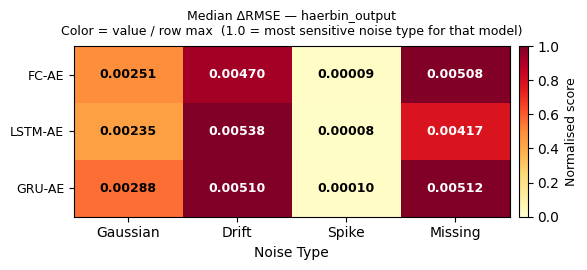

Saved -> haerbin_output\delta_rmse_heatmap.png


In [44]:
# -- Median ΔRMSE Summary Table + Row-normalised Heatmap (from Wilcoxon results) --
# Uses _delta_rmse() and results_B already computed in the Wilcoxon cell above.
# Each row = one model; columns = four noise types; cell = median ΔRMSE.
# Heatmap colour = value / row_max, showing within-model sensitivity ranking.
import matplotlib.pyplot as plt
import numpy as np

_NOISE_KEYS_H = [
    'Gaussian',
    'Drift',
    'Spike',
    'Missing data\n(linear interp.)',
]
_SHORT_H = {
    'Gaussian':                       'Gaussian',
    'Drift':                          'Drift',
    'Spike':                          'Spike',
    'Missing data\n(linear interp.)': 'Missing',
}
_NTYPES_H  = ['Gaussian', 'Drift', 'Spike', 'Missing']
_MODELS_H  = list(results_B.keys())

# ---- Collect median ΔRMSE --------------------------------------------------
_delta_meds = {}   # (model, noise_short) -> median
_summary_rows = []

for _mh in _MODELS_H:
    _dh = _delta_rmse(results_B[_mh])
    _row = {'Model': _mh}
    for _nk in _NOISE_KEYS_H:
        _sh = _SHORT_H[_nk]
        _med = float(np.median(_dh[_nk])) if _nk in _dh else float('nan')
        _row[f'ΔRMSE {_sh}'] = round(_med, 7)
        _delta_meds[(_mh, _sh)] = _med
    _vals = {_SHORT_H[k]: float(np.median(_dh[k])) for k in _NOISE_KEYS_H if k in _dh}
    _row['Ranking'] = ' > '.join(sorted(_vals, key=lambda x: _vals[x], reverse=True))
    _summary_rows.append(_row)

# ---- Display table ---------------------------------------------------------
_df_dh = pd.DataFrame(_summary_rows)
print(f'Dataset: {OUT_DIR}')
display(
    _df_dh.style
    .set_caption(
        'Median ΔRMSE per model × noise type  '
        '(ΔRMSE = RMSE(max noise level) − RMSE(clean), from Wilcoxon results)'
    )
    .format({c: '{:.7f}' for c in _df_dh.columns if 'ΔRMSE' in c})
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size','12px'), ('font-weight','bold'), ('text-align','left')]
    }])
)

# ---- Heatmap ---------------------------------------------------------------
_mat = np.array([[_delta_meds.get((m, n), float('nan'))
                  for n in _NTYPES_H] for m in _MODELS_H])

_rmax = np.nanmax(_mat, axis=1, keepdims=True)
_rmax[_rmax == 0] = 1.0
_pmat = _mat / _rmax   # row-normalised [0, 1]

fig_dh, ax_dh = plt.subplots(figsize=(6, 2.8))
_im_dh = ax_dh.imshow(_pmat, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)

for ri in range(_mat.shape[0]):
    for ci in range(_mat.shape[1]):
        _v = _mat[ri, ci]
        if not np.isnan(_v):
            _c = 'white' if _pmat[ri, ci] > 0.65 else 'black'
            ax_dh.text(ci, ri, f'{_v:.5f}', ha='center', va='center',
                       fontsize=9, color=_c, fontweight='bold')

ax_dh.set_xticks(range(len(_NTYPES_H)))
ax_dh.set_xticklabels(_NTYPES_H, fontsize=10)
ax_dh.set_yticks(range(len(_MODELS_H)))
ax_dh.set_yticklabels(_MODELS_H, fontsize=9)
ax_dh.set_xlabel('Noise Type', fontsize=10)
ax_dh.set_title(
    f'Median ΔRMSE — {OUT_DIR}\n'
    'Color = value / row max  (1.0 = most sensitive noise type for that model)',
    fontsize=9, pad=8)
_cb_dh = fig_dh.colorbar(_im_dh, ax=ax_dh, fraction=0.04, pad=0.02)
_cb_dh.set_label('Normalised score', fontsize=9)
fig_dh.tight_layout()
_hmap_path = os.path.join(OUT_DIR, 'delta_rmse_heatmap.png')
plt.savefig(_hmap_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {_hmap_path}')
